In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import datetime 

import os
if os.name == 'posix' :
    plt.rc('font', family='AppleGothic')
else :
    plt.rc('font', family='Malgun Gothic')
    
plt.rc('axes', unicode_minus=False)

In [2]:
from sklearn.preprocessing import RobustScaler # 스케일러
from sklearn.cluster import KMeans # 거리 기반 클러스터링
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree  # 계층적 클러스터링
from sklearn.cluster import DBSCAN # DBSCAN 클러스터링
from sklearn.mixture import GaussianMixture # GMM 클러스터링
from sklearn.decomposition import PCA # 차원 축소 - 주성분
from sklearn.ensemble import RandomForestClassifier # 랜덤포레스트 - 속성 중요도
from sklearn.model_selection import train_test_split # 학습 데이터, 테스트 데이터 나누기
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score # 실루엣점수

In [36]:
merge = pd.read_csv('./merged_final_please_df.csv')
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,...,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,...,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,...,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,...,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,...,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# 네이버지도 기준

merge.loc[merge['start_point_name'] == '송추분소', 'dist_to_nearest_parking_km'] = 0.410 # 북한산국립공원 송추제2주차장
merge.loc[merge['start_point_name'] == '백운탐방지원센터', 'dist_to_nearest_parking_km'] = 0.071 # 도선사광장주차장
merge.loc[merge['start_point_name'] == '구기탐방지원센터', 'dist_to_nearest_parking_km'] = 0.775 # 비봉공영주차장
merge.loc[merge['start_point_name'] == '비봉탐방지원센터', 'dist_to_nearest_parking_km'] = 0.815 # 비봉공영주차장
merge.loc[merge['start_point_name'] == '백련공원지킴터', 'dist_to_nearest_parking_km'] = 0.21   # 아카데미공영주차장
merge.loc[merge['start_point_name'] == '소귀천공원지킴터', 'dist_to_nearest_parking_km'] = 0.128 # 할렐루야기도원 주차장
merge.loc[merge['start_point_name'] == '증심교', 'dist_to_nearest_parking_km'] = 0.526 # 증심사이주단지 공영 주차장 
merge.loc[merge['start_point_name'] == '너릿재 체육쉼터', 'dist_to_nearest_parking_km'] = 3.8 # 너릿재유아숲 공영 주차장
merge.loc[merge['start_point_name'] == '도원탐방지원센터', 'dist_to_nearest_parking_km'] = 0.028 # 도원마을쉼터주차장
merge.loc[merge['start_point_name'] == '장수대분소', 'dist_to_nearest_parking_km'] = 0.365 # 설악산국립공원 한계산성분소 주차장
merge.loc[merge['start_point_name'] == '남설악탐방지원센터', 'dist_to_nearest_parking_km'] = 0.414 # 오색그린야드호텔 공영 주차장
merge.loc[merge['start_point_name'] == '영각탐방지원센터', 'dist_to_nearest_parking_km'] = 1 # 이름이 주차장..? -> 영각사주차장

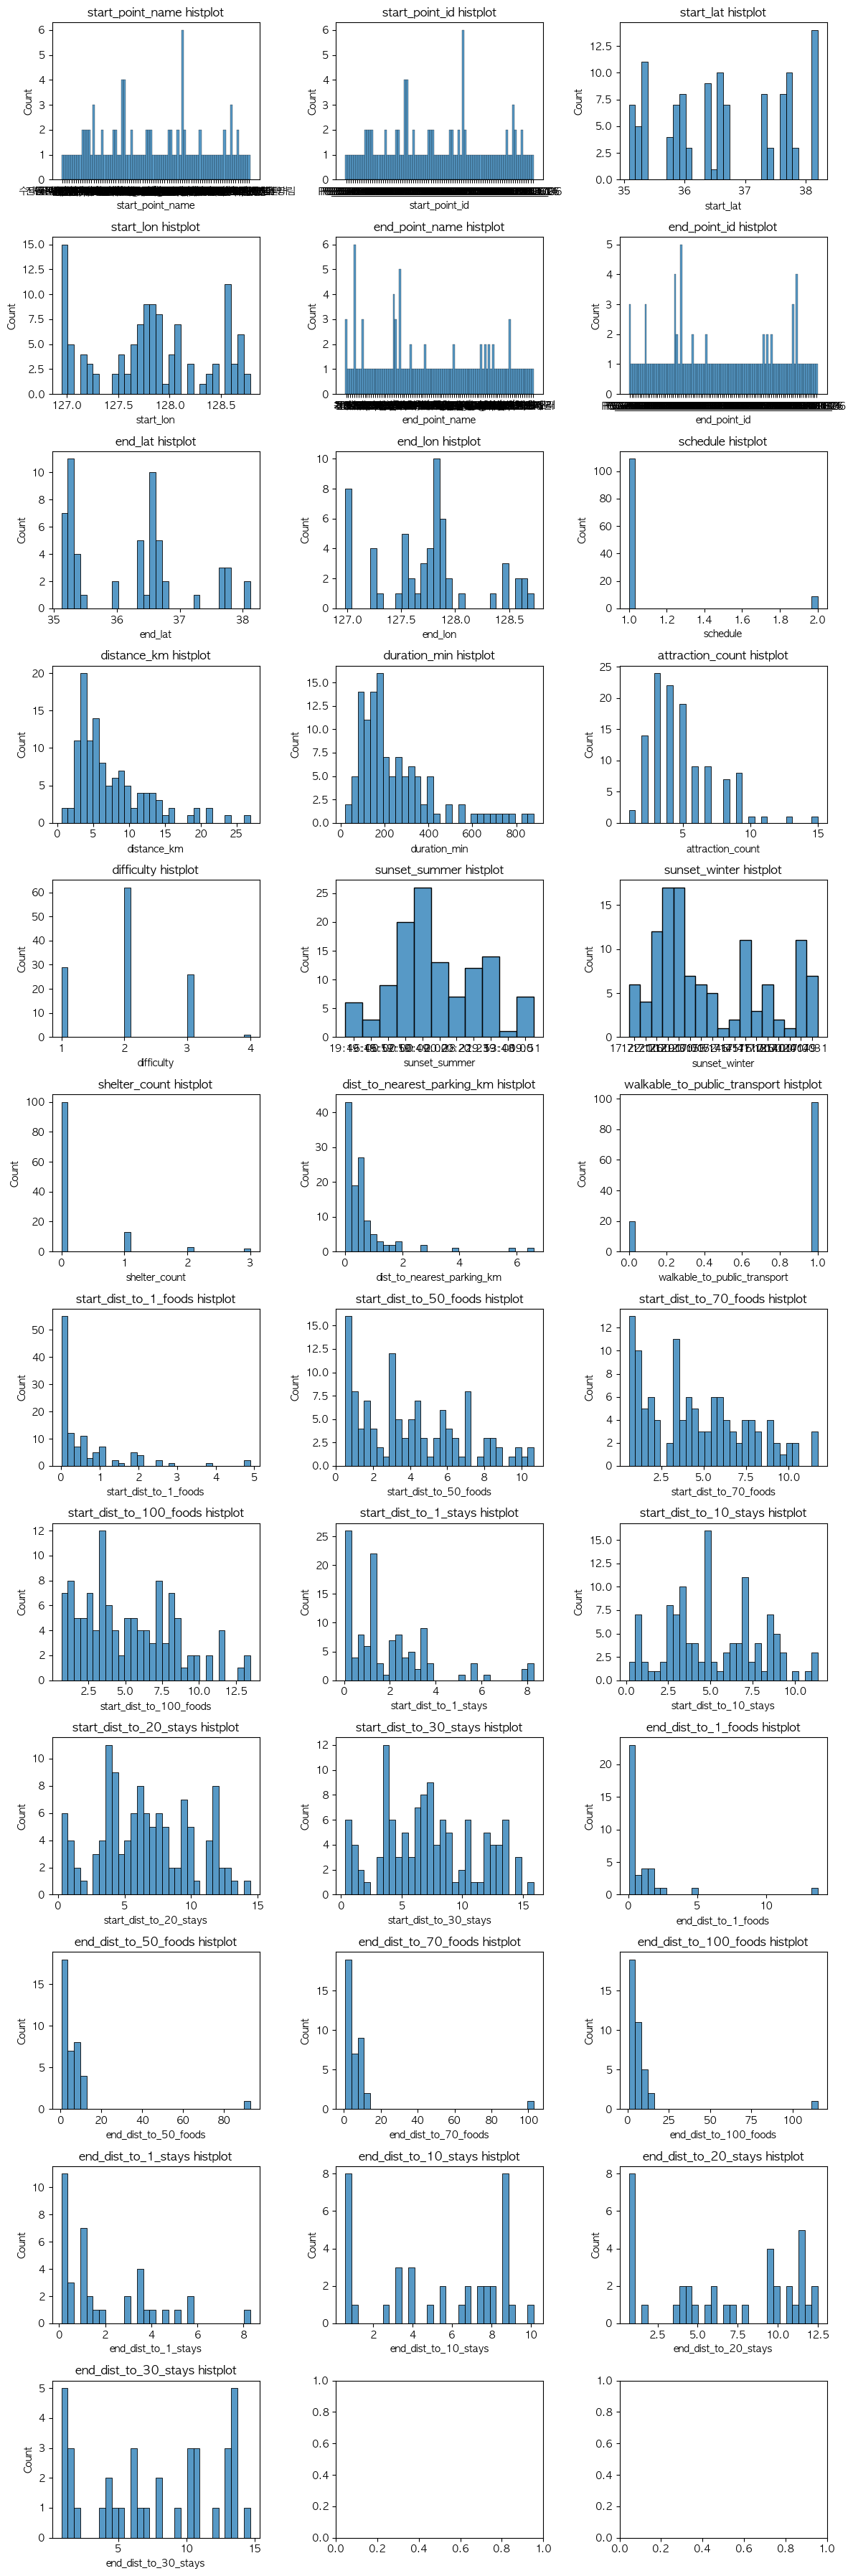

In [5]:
# 0번 컬럼은 고객 id 이므로, 이를 제외하고 컬럼 접근
# 시간을 나타내는 object 타입 컬럼들도 제거해준다
col = list(merge.drop(columns=['mountain_name', 'course_name', 'course_id', 'attraction_list', 'start_place_ID','end_place_ID']).columns)

def hist_subplots(dataFrame, col_cnt, bin_cnt) :
    # 3개의 컬럼으로 형성되는 subplots
    col_count = col_cnt
    #  // 는 버림처리가 되지만, 현재는 올림처리가 필요하므로 음수를 활용해서 절대값이 올림처리 되게 한 다음 다시 음수를 추가해서 양수 변환시키기
    row_count = -(-len(col)//col_count)

    # subplots 형태
    fig, axs = plt.subplots(row_count, col_count, figsize=(col_count*4, row_count*3))
    # 접근을 위한 1차원 변환
    axs = axs.flatten()

    for i, c in enumerate(col) :
        sns.histplot(data=dataFrame, x=c, bins=bin_cnt, ax = axs[i])
        axs[i].set_title(c +' histplot')
        
    plt.tight_layout()
    plt.show()
    
hist_subplots(merge, 3, 30)

- 정규분포 X -> elbow method로 k개수 찾기

> 상관계수 확인

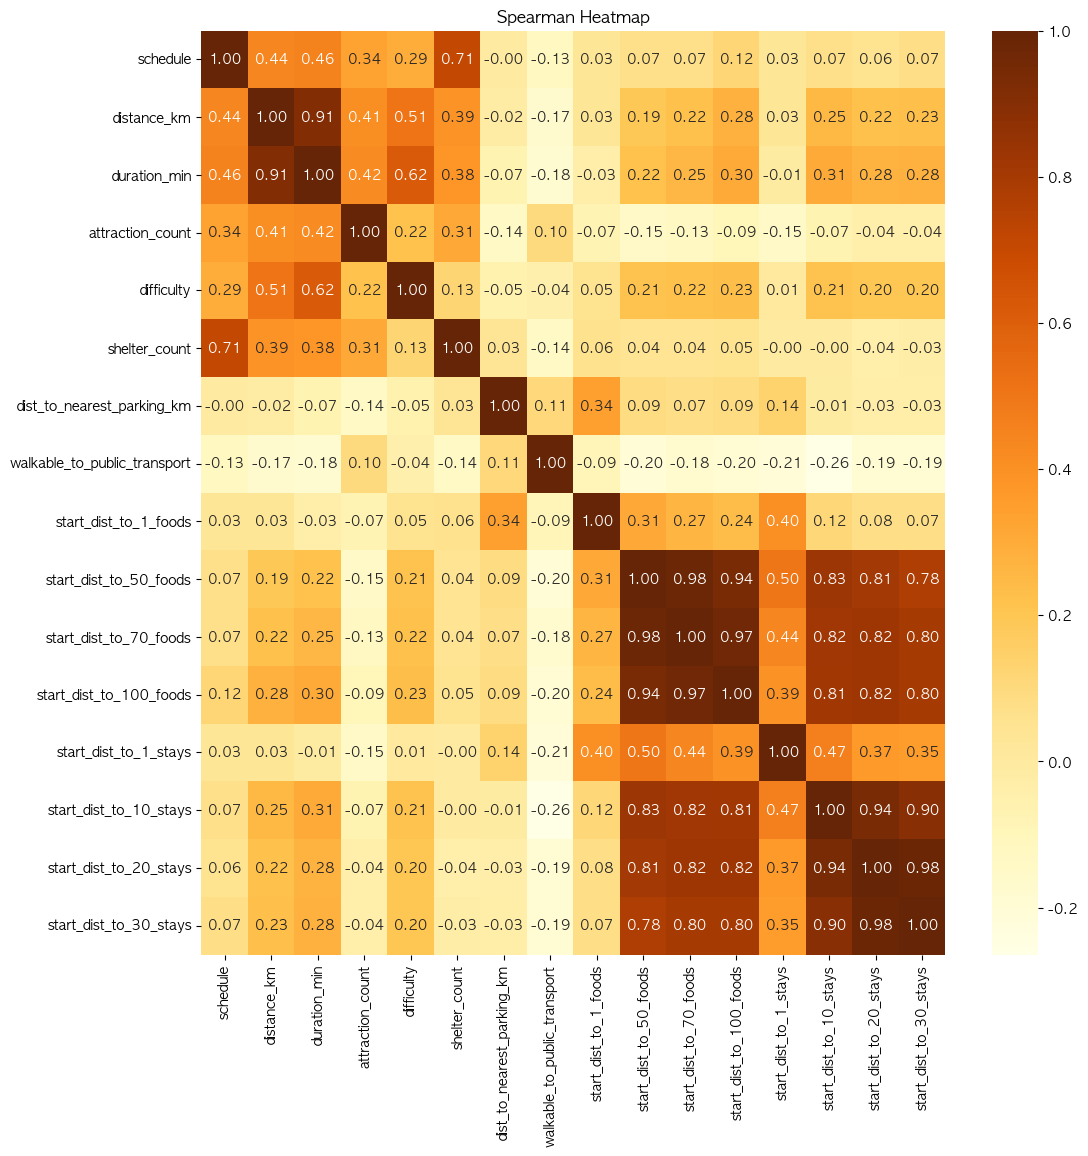

In [6]:
# id 와 같은 컬럼 제거해서 히트맵 확인
# 순서 중심의 클러스터링 진행할 변수들만 추출해서 스피어만 상관계수 구하기

# 일몰 시간은 수치형 변수라고 하기 어려워서 우선 제거

df_heatmap = merge[['schedule', 'distance_km','duration_min','attraction_count', 'difficulty',
        'shelter_count',
       'dist_to_nearest_parking_km', 'walkable_to_public_transport', 
       'start_dist_to_1_foods', 'start_dist_to_50_foods',
       'start_dist_to_70_foods', 'start_dist_to_100_foods',
       'start_dist_to_1_stays', 'start_dist_to_10_stays',
       'start_dist_to_20_stays', 'start_dist_to_30_stays']]
# 히트맵 그려보기
plt.figure(figsize=(12,12))
sns.heatmap(df_heatmap.corr(method='spearman'), annot=True, cmap='YlOrBr', fmt='.2f')
plt.title('Spearman Heatmap')
plt.show()

> start_dist_to_1_food, start_dist_to_1_stays 는 다른 여러개와 상관이 크지 않음
- 음식점 50개, 숙소 10개는 1개와 상관계수가 0.5 이상이므로 우선 음식점은 100개랑 숙소는 30개로 다뤄보기
- 거리랑 소요시간도 강한 상관관계
- 일정과 대피소의 개수도 강한 상관관계
> 이때 변수 간 상관관계가 너무 높으면, 중복된 정보를 두 번 반영하게 되어 왜곡된 거리가 생길 수 있음

In [37]:
# 사분위수 기준값 구하기
q1 = merge['dist_to_nearest_parking_km'].quantile(0.25)
q2 = merge['dist_to_nearest_parking_km'].quantile(0.50)
q3 = merge['dist_to_nearest_parking_km'].quantile(0.75)

# 박스플롯 기준 상한 (이상치 기준값)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# 라벨링 함수 정의
def label_parking_dist(x):
    if x > upper_bound:
        return 4  # 이상치
    elif x <= q1:
        return 0
    elif x <= q2:
        return 1
    elif x <= q3:
        return 2
    else:
        return 3

# 적용
merge['dist_to_nearest_parking_km_cate'] = merge['dist_to_nearest_parking_km'].apply(label_parking_dist)
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,dist_to_nearest_parking_km_cate
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


## PCA를 통한 클러스터링

In [38]:
# 필요한 컬럼만 남기기
df_drop = merge[['schedule', 'distance_km','duration_min','attraction_count', 'difficulty',
                  'shelter_count',
                 'dist_to_nearest_parking_km_cate', 'walkable_to_public_transport',
                 'start_dist_to_1_foods', 'start_dist_to_50_foods',
                'start_dist_to_70_foods', 'start_dist_to_100_foods',
                'start_dist_to_1_stays', 'start_dist_to_10_stays',
                'start_dist_to_20_stays', 'start_dist_to_30_stays']]

In [39]:
# 연속형
continuous_cols = ['distance_km','duration_min','dist_to_nearest_parking_km_cate','start_dist_to_1_foods', 'start_dist_to_50_foods',
                'start_dist_to_70_foods', 'start_dist_to_100_foods',
                'start_dist_to_1_stays', 'start_dist_to_10_stays',
                'start_dist_to_20_stays', 'start_dist_to_30_stays', 'attraction_count']

# 수치형
categorical_cols = ['schedule', 'difficulty', 'shelter_count','walkable_to_public_transport']

# 연속형 변수 스케일링
scaler_cont = StandardScaler()
scaled_cont = scaler_cont.fit_transform(df_drop[continuous_cols])

# 범주형 변수 스케일링
scaler_cat = MinMaxScaler()
scaled_cat = scaler_cat.fit_transform(df_drop[categorical_cols])

scaled_total = np.concatenate([scaled_cont, scaled_cat], axis=1)
scaled_df = pd.DataFrame(scaled_total, columns=continuous_cols + categorical_cols)

scaled_df.head()

,distance_km,duration_min,dist_to_nearest_parking_km_cate,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,attraction_count,schedule,difficulty,shelter_count,walkable_to_public_transport
0,-0.744213,-0.761733,-0.453172,-0.337757,-0.766575,-0.211023,-0.301747,-0.584020,-0.178393,-0.094164,0.021304,-0.363088,0.0,0.333333,0.0,1.0
1,-0.574720,-0.537302,-1.239559,-0.040946,-0.914797,-0.892406,-0.853595,-0.341511,-0.911008,-0.314388,0.437913,0.037327,0.0,0.000000,0.0,1.0
2,-0.395258,-0.340925,1.119602,-0.084918,0.751803,0.564345,0.402334,-0.088458,0.517591,0.654598,0.862285,0.037327,0.0,0.333333,0.0,1.0
3,-0.255675,-0.228710,1.905989,0.937430,-0.249603,-0.264728,-0.231973,0.401831,1.001117,1.036319,1.320297,0.037327,0.0,0.333333,0.0,1.0
4,0.163071,0.388474,-0.453172,-0.249813,-0.643658,-0.345286,-0.393722,-0.230801,-0.108795,-0.191063,-0.149480,0.037327,0.0,0.666667,0.0,1.0


In [40]:
# 주성분 수 구하기

pca_all = PCA()
pca_all.fit(scaled_df) # scaled_df 모든 컬럼
pca_all_df = pd.DataFrame(pca_all.transform(scaled_df))

# 모든 컬럼에 대한 누적 분산 비율
cumsum_var = np.cumsum(pca_all.explained_variance_ratio_) 
# 데이터프레임으로 누적 분산 봐보기
cumsum_var_df = pd.DataFrame({'cumsum_var' : cumsum_var}, index = pca_all_df.columns)
cumsum_var_df

,cumsum_var
0,0.476267
1,0.665930
2,0.768239
3,0.837076
4,0.890703
5,0.930750
6,0.965662
7,0.976431
8,0.983263
9,0.988799


- 누적 설명력 80% 이상을 위해서 주성분 수 4개로 결정하였습니다.

In [41]:
def pca_func(df, components) : # 적용할 데이터랑 주성분 수
    # PCA 주성분 2개 구하기 위한 변수 생성
    X = df.copy()

    # 객체
    pca = PCA(n_components= components)

    # 적용
    pca.fit(X)
    x_pca = pca.transform(X)
    pca_df = pd.DataFrame(x_pca)
    
    # 앞서 구한 주성분이 각각 전체 데이터에서 어느 정도의 설명력을 가지는지 확인
    # -> 전체 분산 대비 어느 정도의 분산 비율을 가지는지 확인
    var = pca.explained_variance_ratio_ 
    # 주성분 구한 데이터프레임과 각 주성분의 분산 비율을 함께 리턴해주기
    return pca_df, var

pca_4_df, var_2 = pca_func(scaled_df, 4)
pca_4_df.head()

,0,1,2,3
0,-0.959257,-0.856718,-0.829110,0.005025
1,-1.590448,-0.380365,-1.019941,-0.948095
2,1.344013,-0.586705,0.029966,1.125390
3,1.254129,-0.537631,0.863195,1.036901
4,-0.777916,0.515044,-0.320755,-0.159960


In [42]:
pca_4_df.columns = ['PC1', 'PC2', 'PC3', 'PC4']  # 컬럼 이름 붙이기

> Elbow method

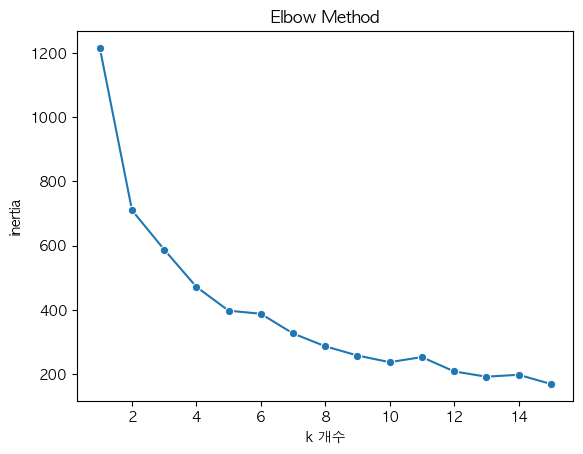

In [43]:
ks = range(1, 16) # k 의 수 범위 정하기ㅏ 1~15
inertias = []

for k in ks :
    model = KMeans(n_clusters = k)
    model.fit(pca_4_df)
    inertias.append(model.inertia_)
    
# 시각화
sns.lineplot(x=ks, y=inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('k 개수')
plt.ylabel('inertia')
plt.show()

In [47]:
# elbow method의 값인 6을 k로 하여서 KMeans
model = KMeans(n_clusters=5,  random_state=6)
model.fit(pca_4_df)
# 고객마다 부여할 클러스터
labels = model.labels_
# PCA 진행한 데이터프레임에 클러스터 번호 부여
pca_km5_df = pca_4_df.copy()
pca_km5_df['label'] = labels
pca_km5_df.head()

,PC1,PC2,PC3,PC4,label
0,-0.959257,-0.856718,-0.829110,0.005025,0
1,-1.590448,-0.380365,-1.019941,-0.948095,0
2,1.344013,-0.586705,0.029966,1.125390,3
3,1.254129,-0.537631,0.863195,1.036901,3
4,-0.777916,0.515044,-0.320755,-0.159960,0


In [48]:
# 실루엣 점수 계산
score = silhouette_score(pca_km5_df, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.455


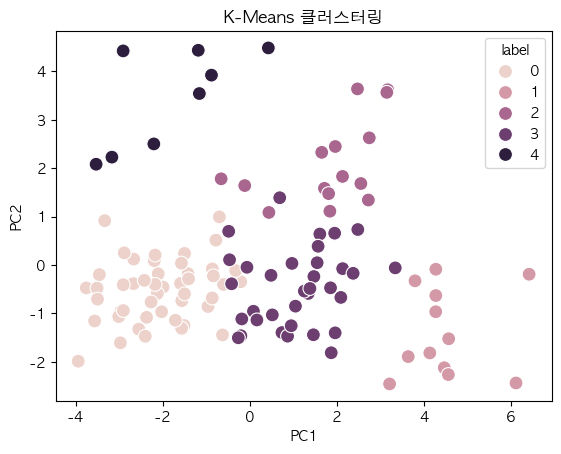

In [49]:
# 데이터를 가장 잘 설명하는 주성분 1, 2 로 scatterplot 그려보기
sns.scatterplot(data=pca_km5_df, x='PC1', y='PC2', hue='label', s=100)
plt.title('K-Means 클러스터링')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [50]:
pca_km5_df['label'].value_counts()

label
0    49
3    34
2    15
1    12
4     8
Name: count, dtype: int64

In [53]:
original_with_label = merge.copy()
original_with_label['label'] = pca_km5_df['label'].values

original_with_label.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,dist_to_nearest_parking_km_cate,label
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0


/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


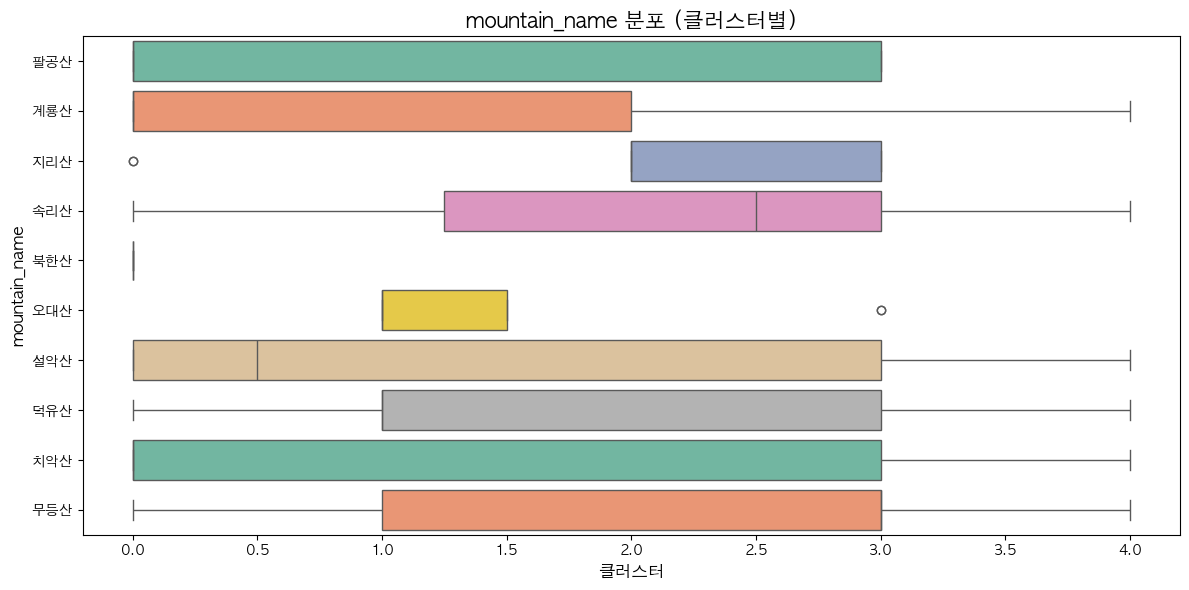

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


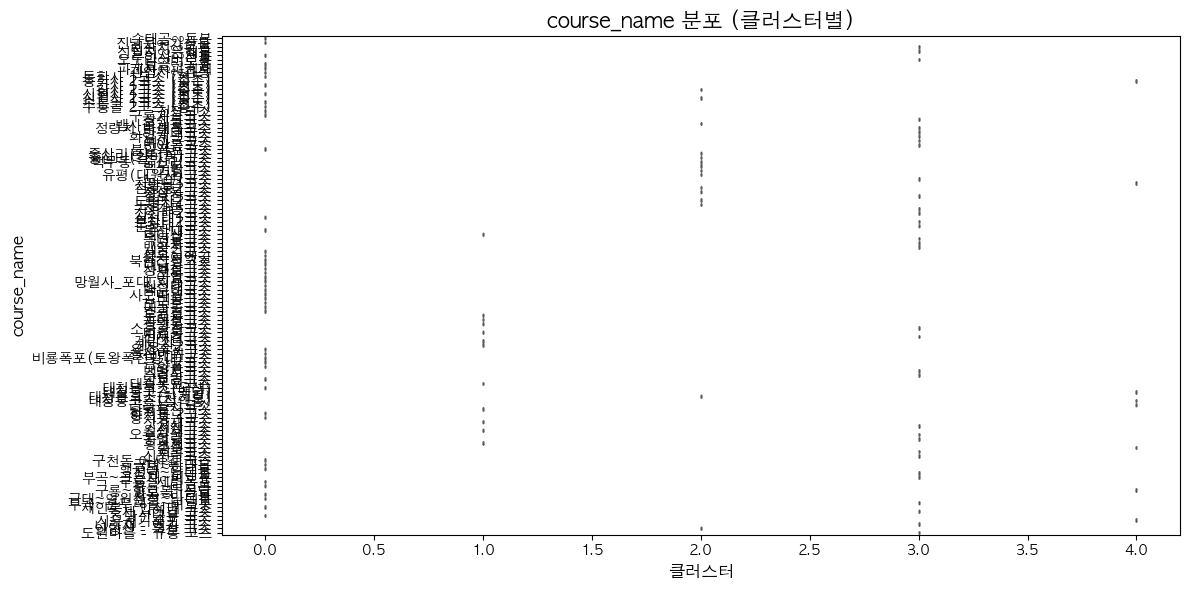

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


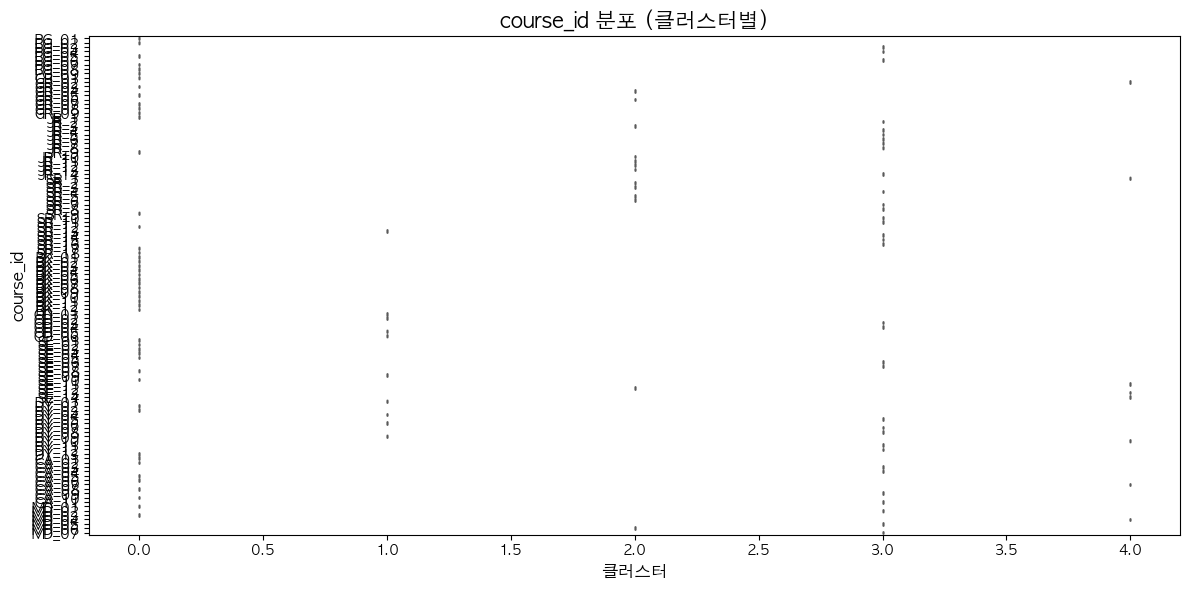

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


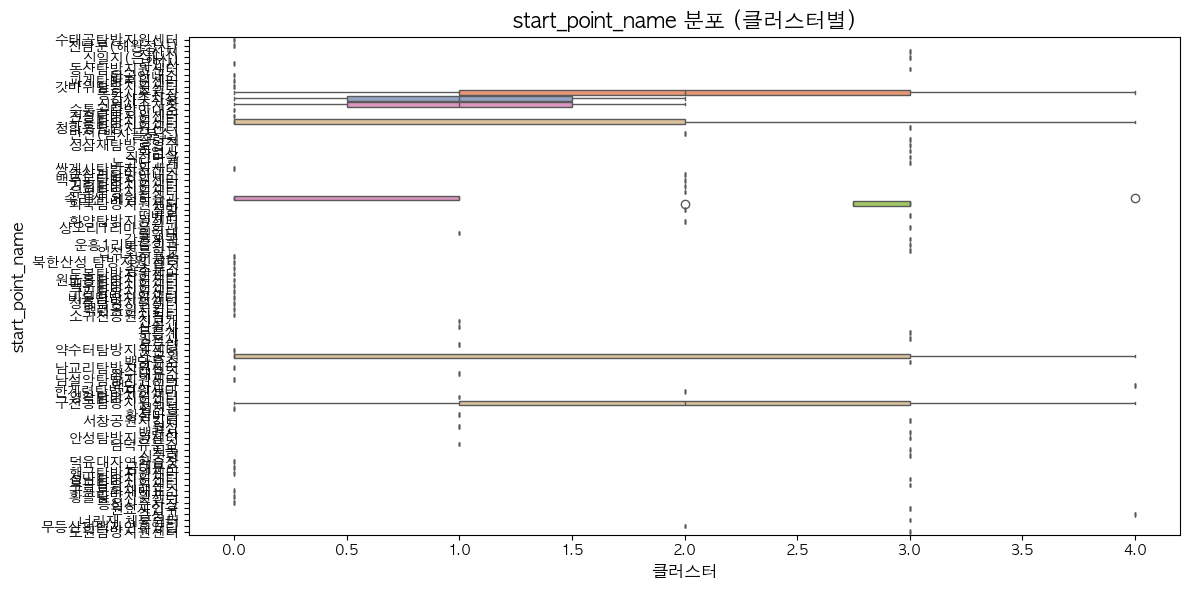

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


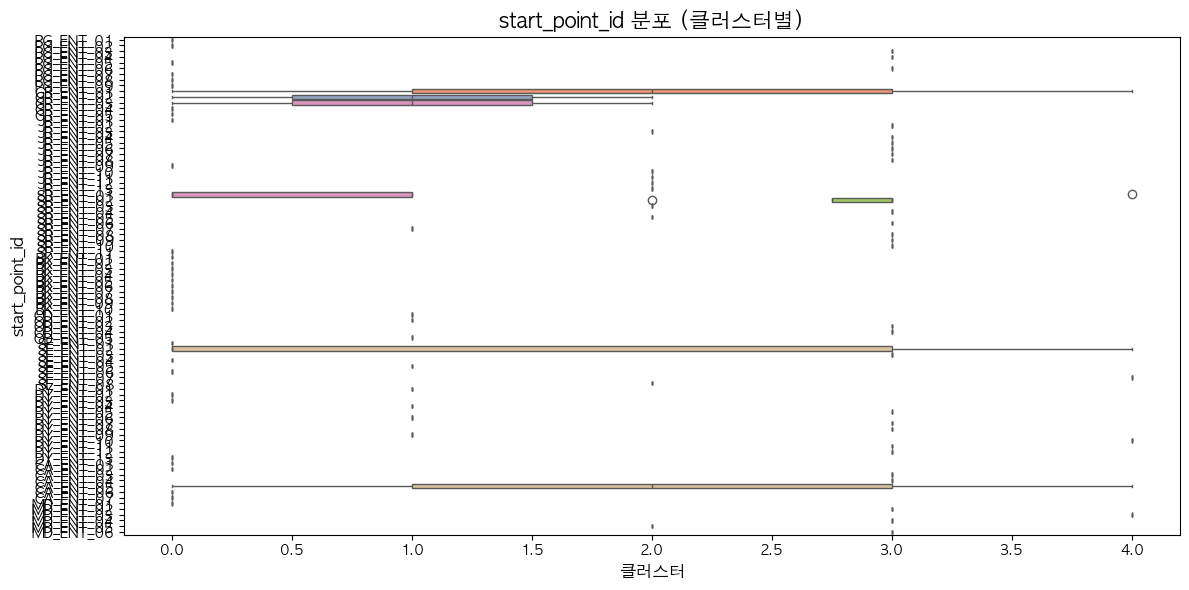

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


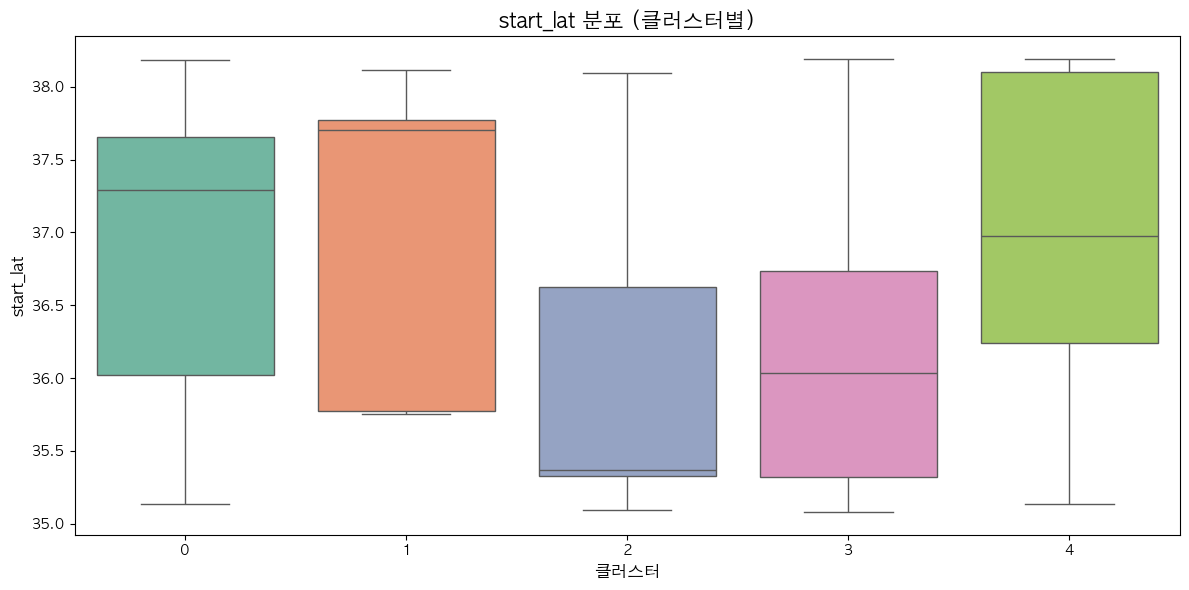

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


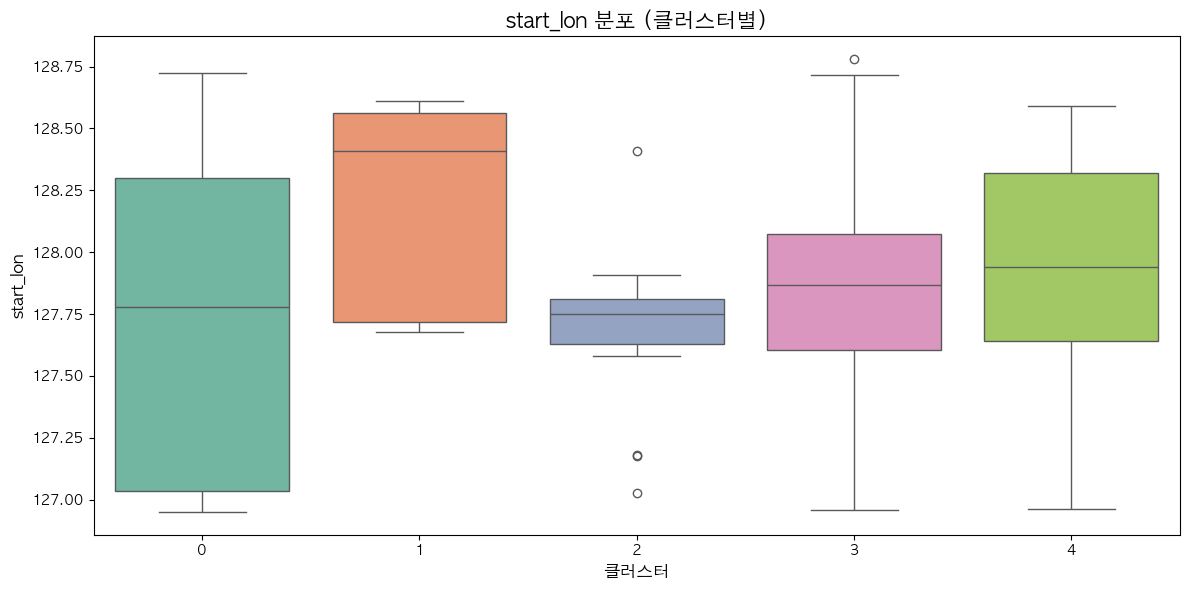

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


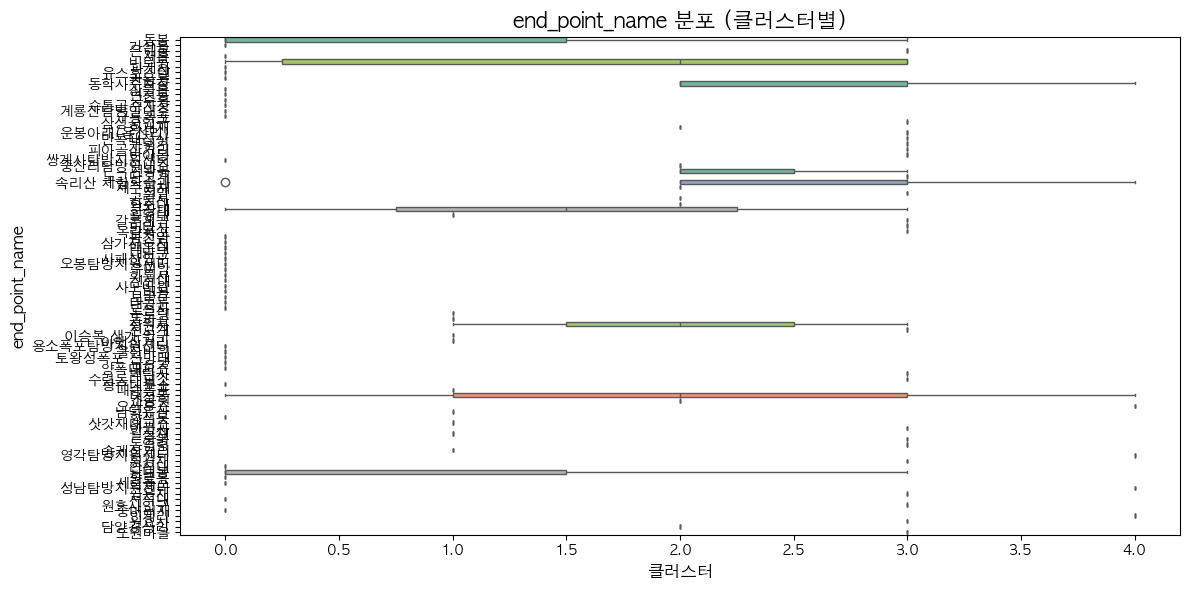

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


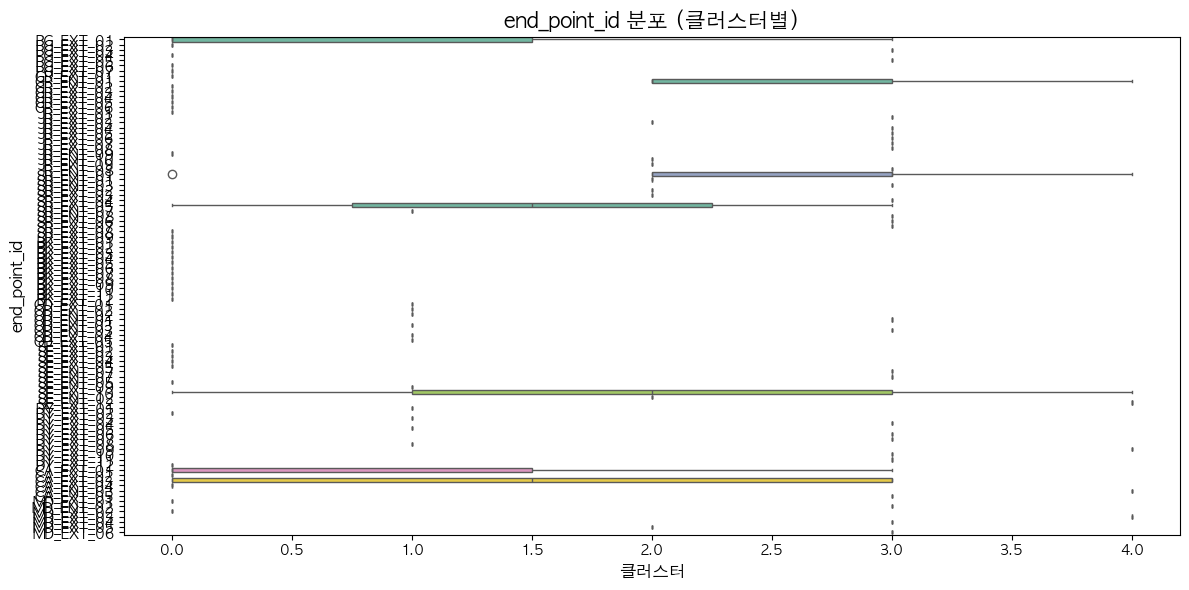

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


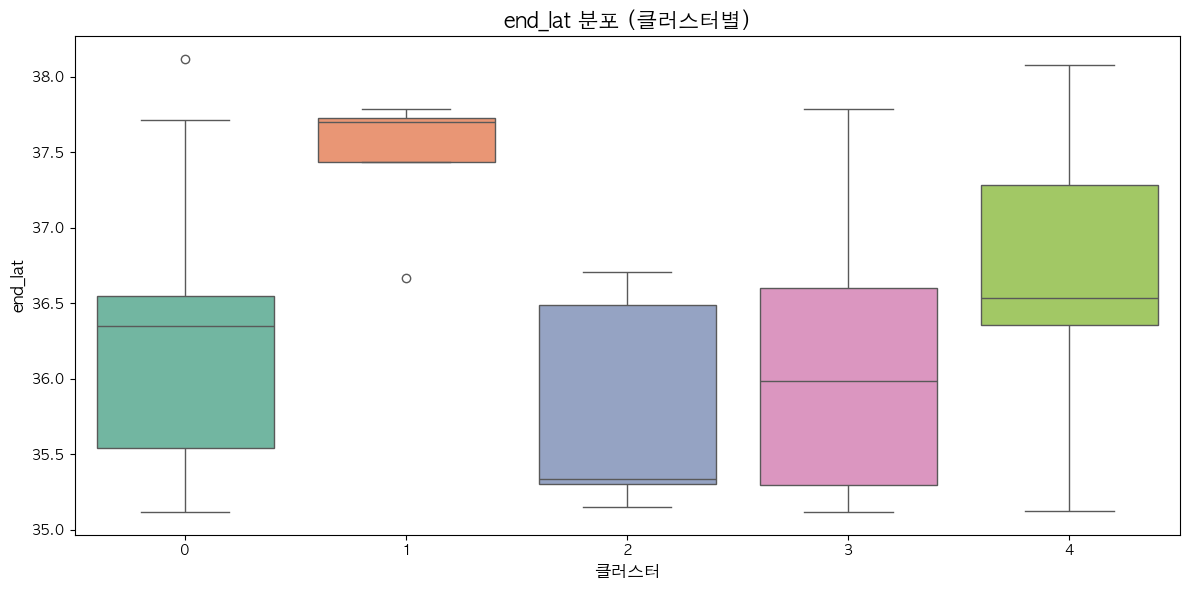

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


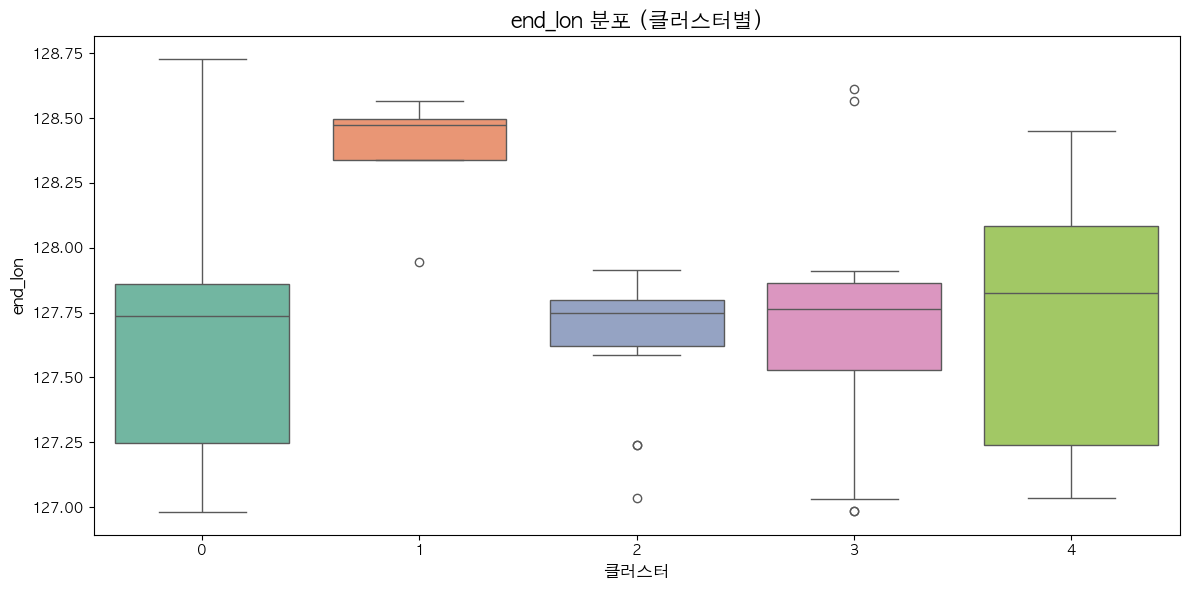

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


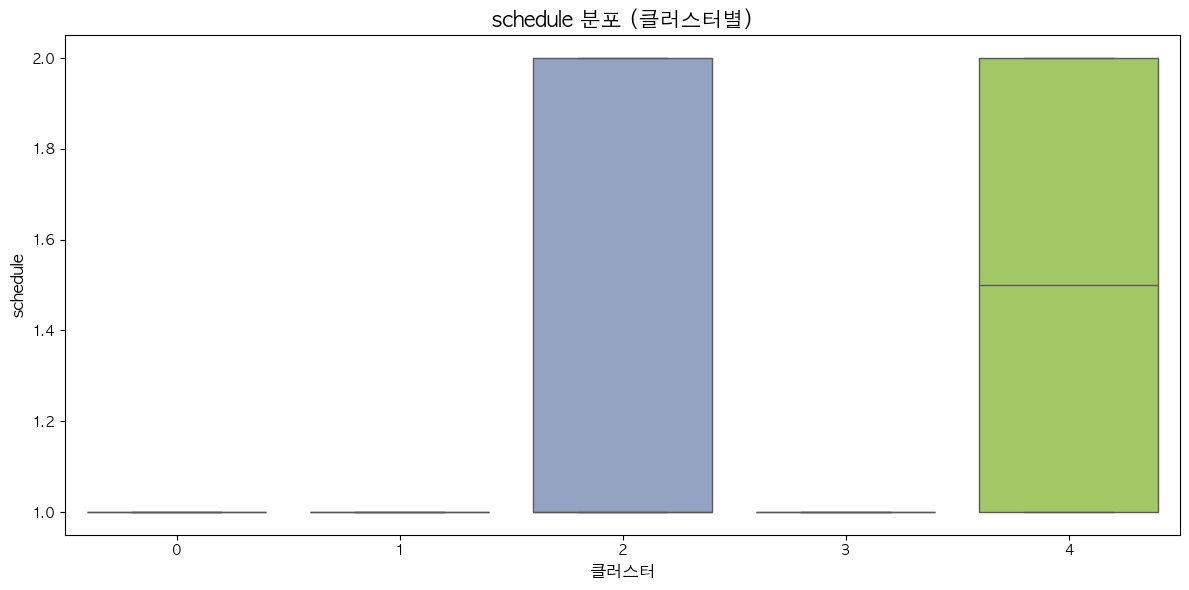

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


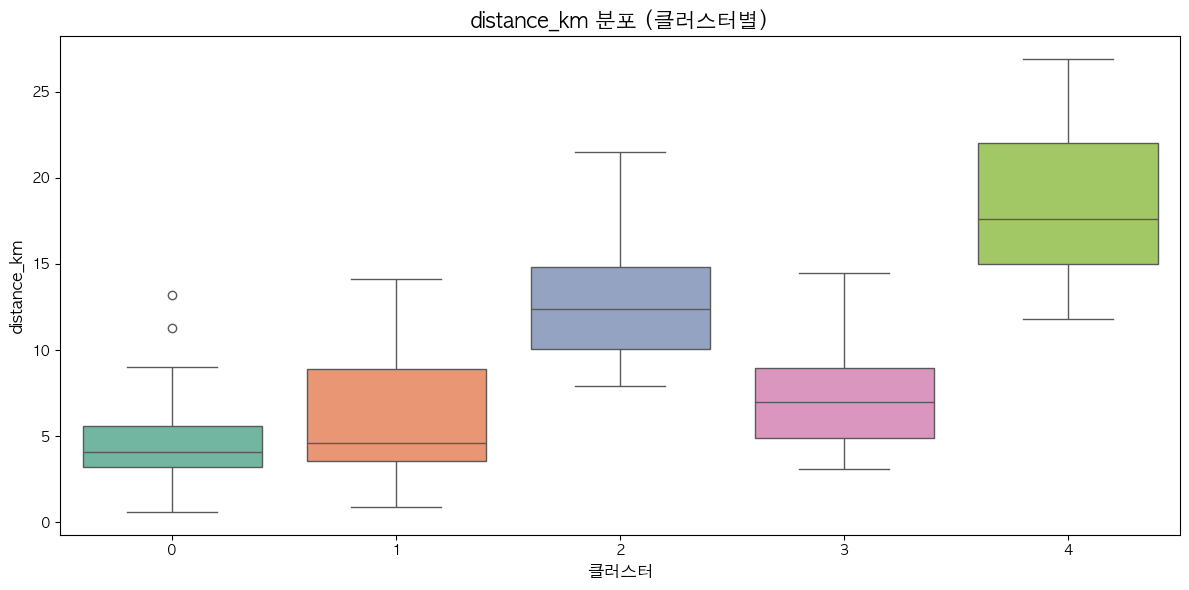

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


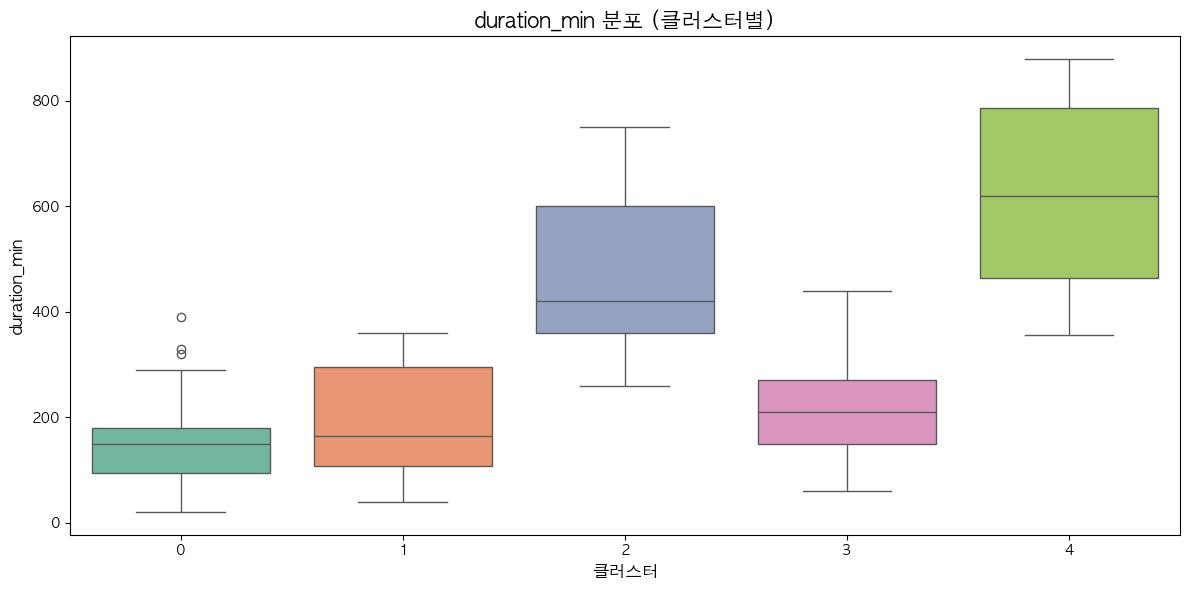

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


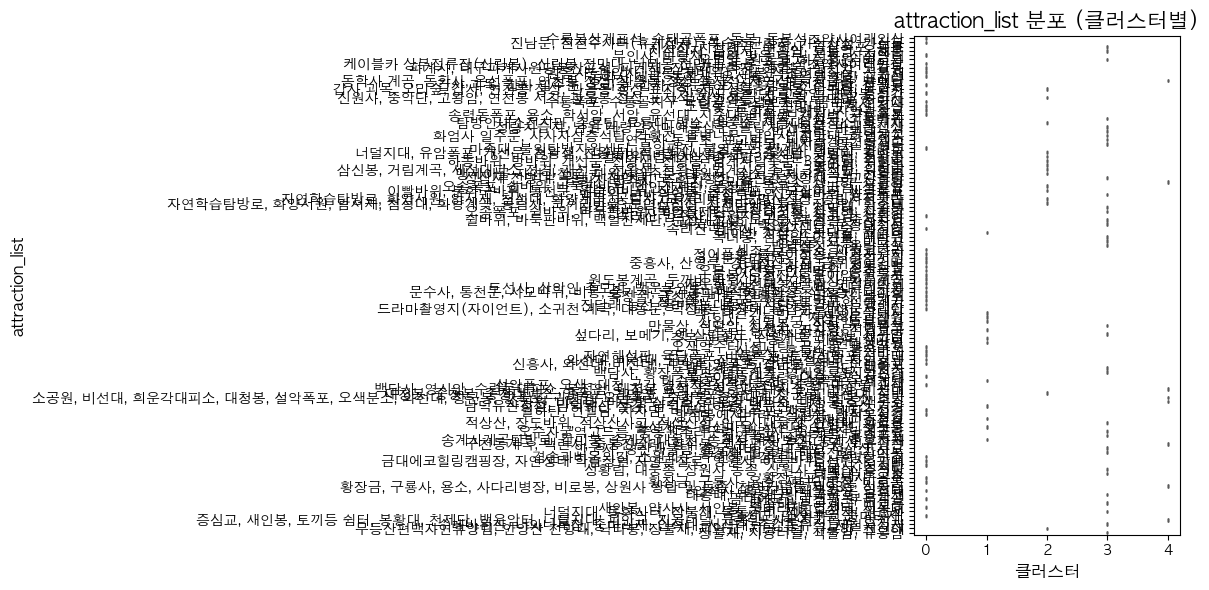

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


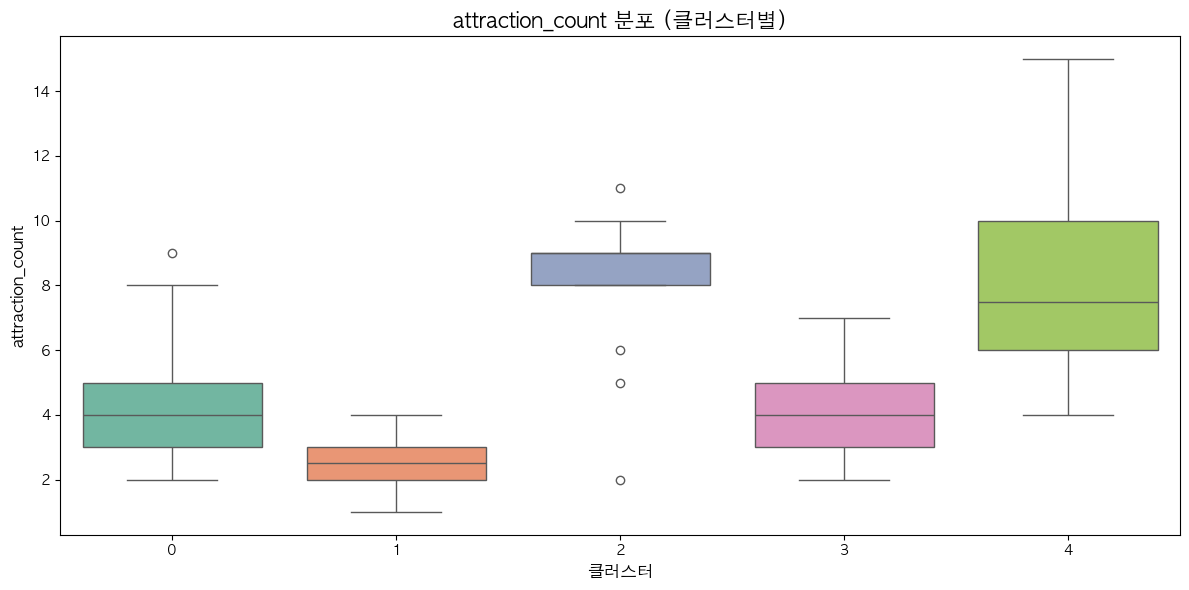

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


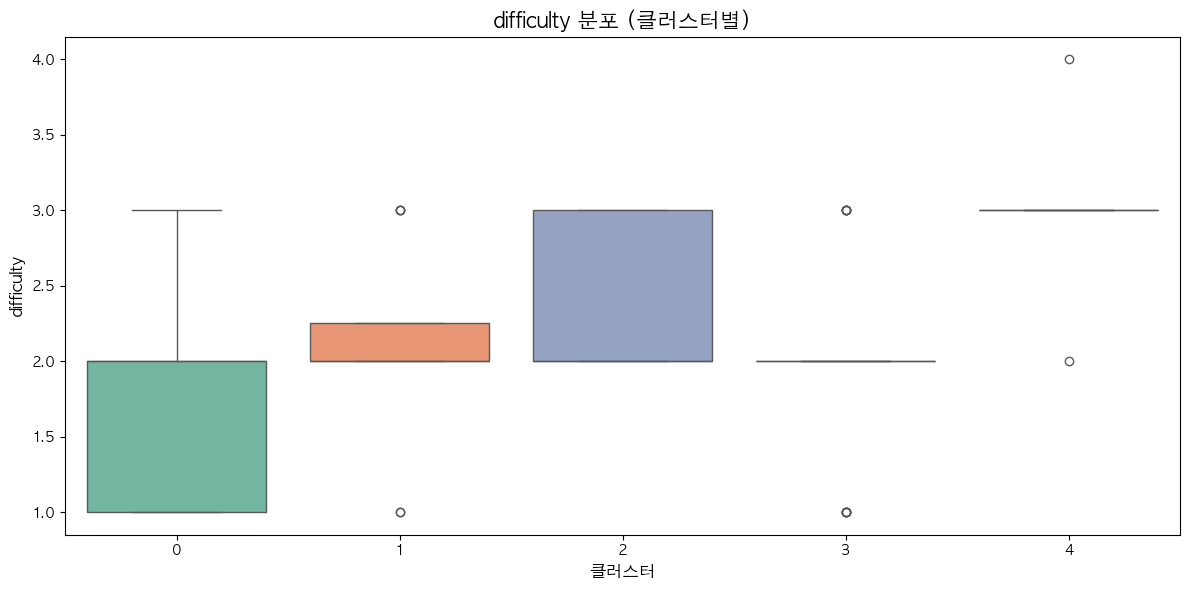

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


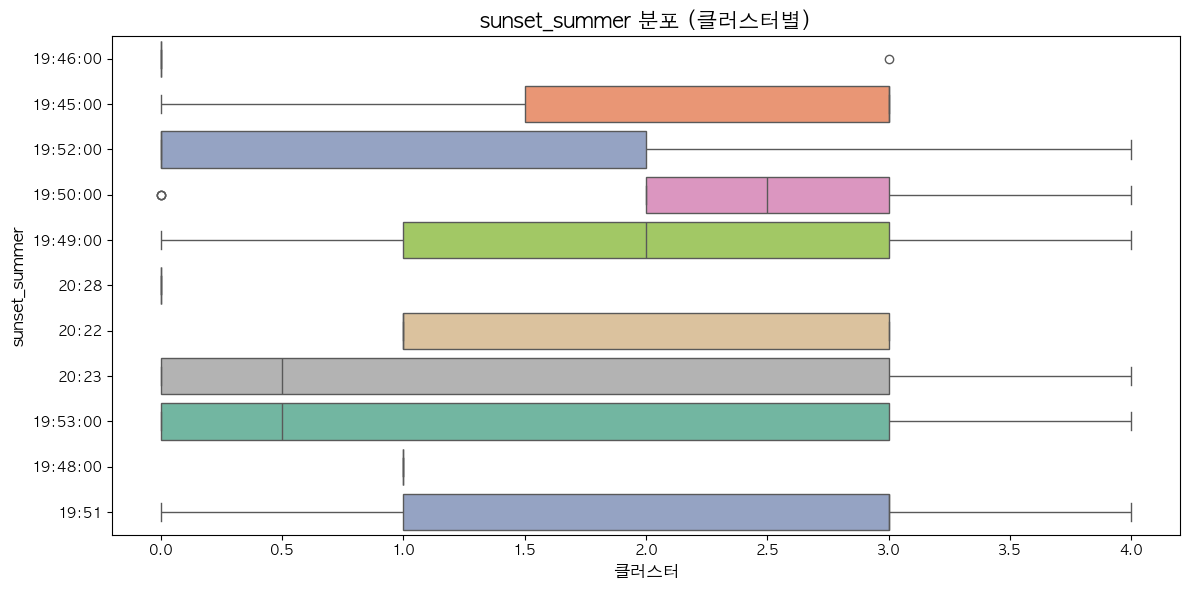

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


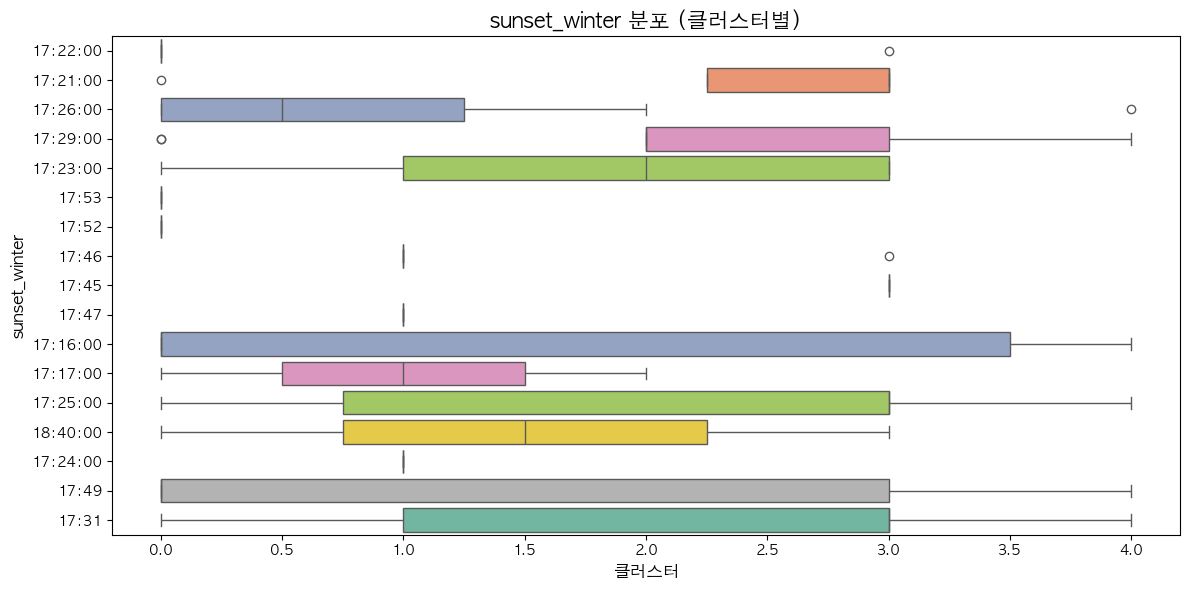

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


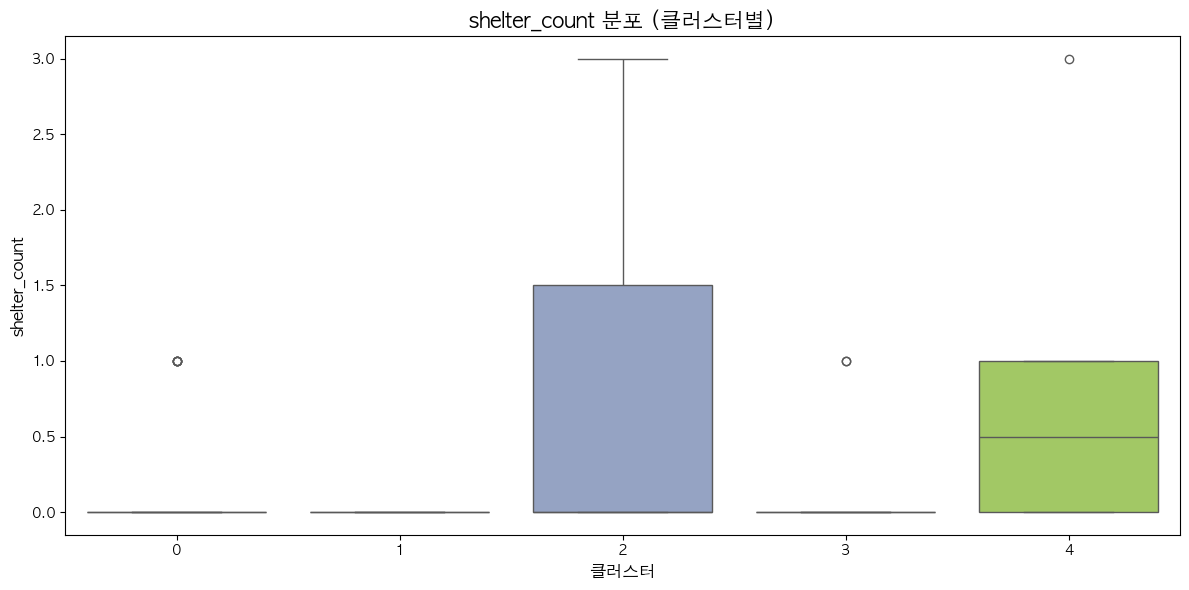

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


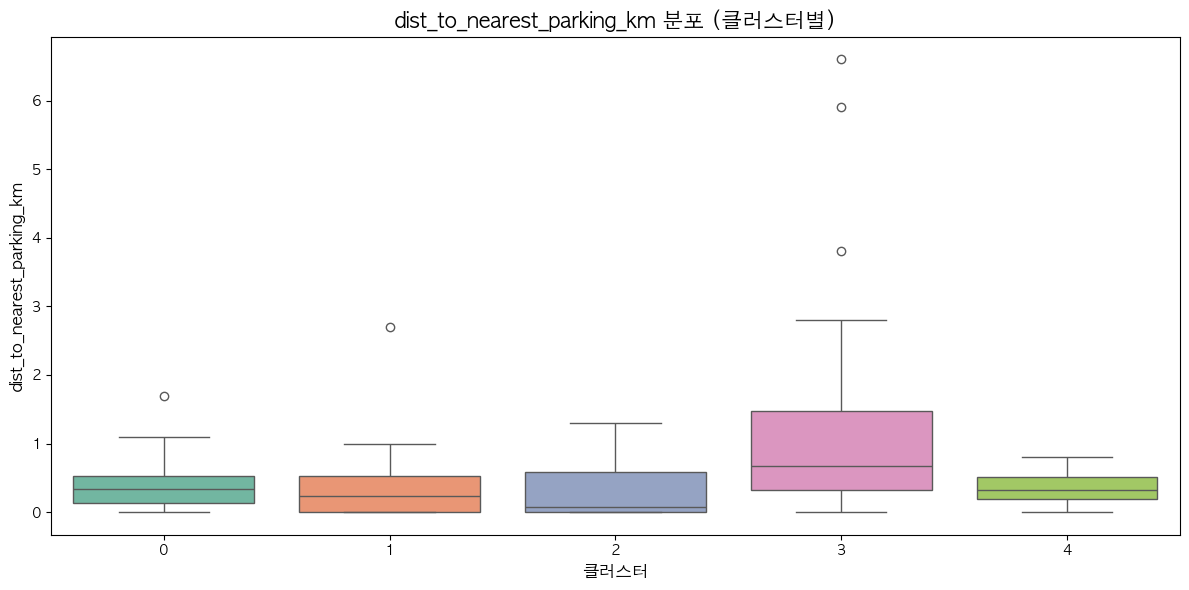

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


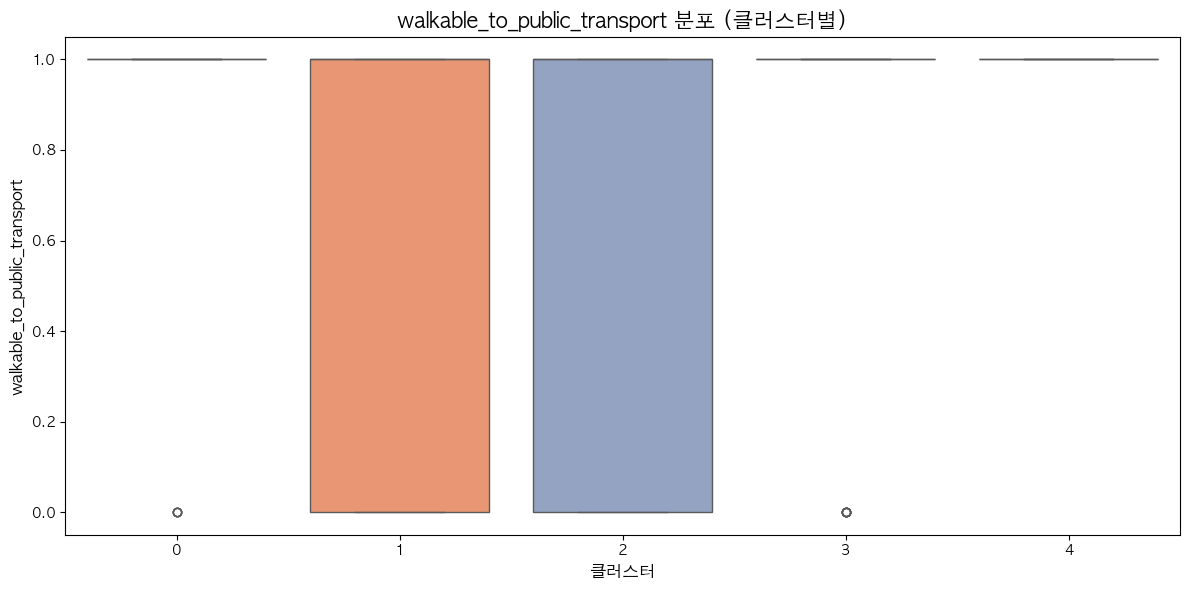

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


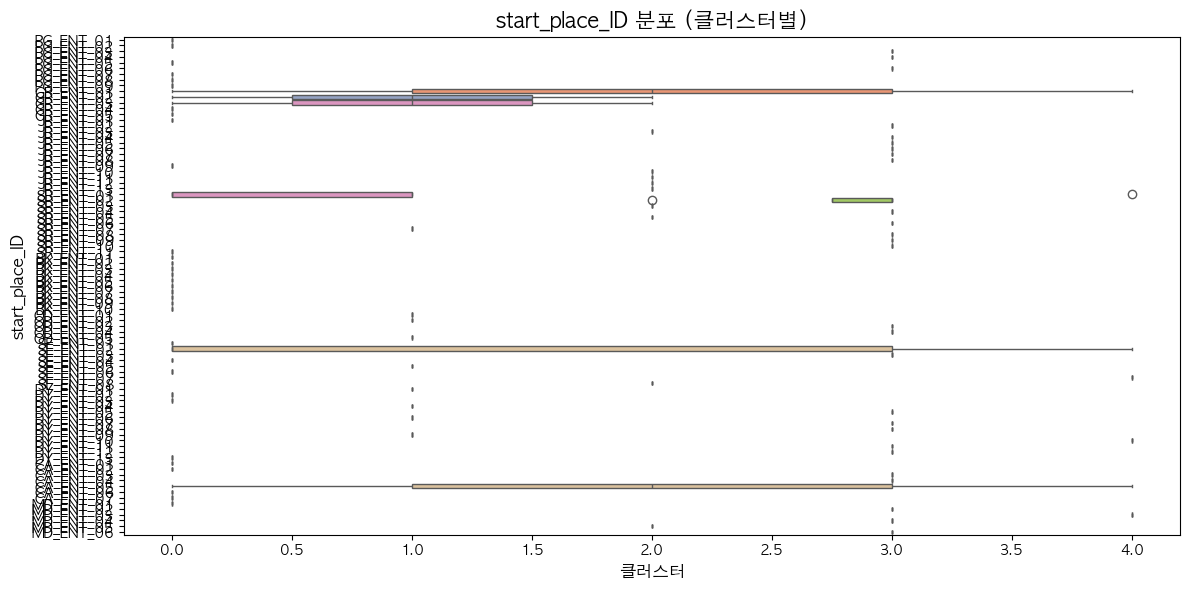

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


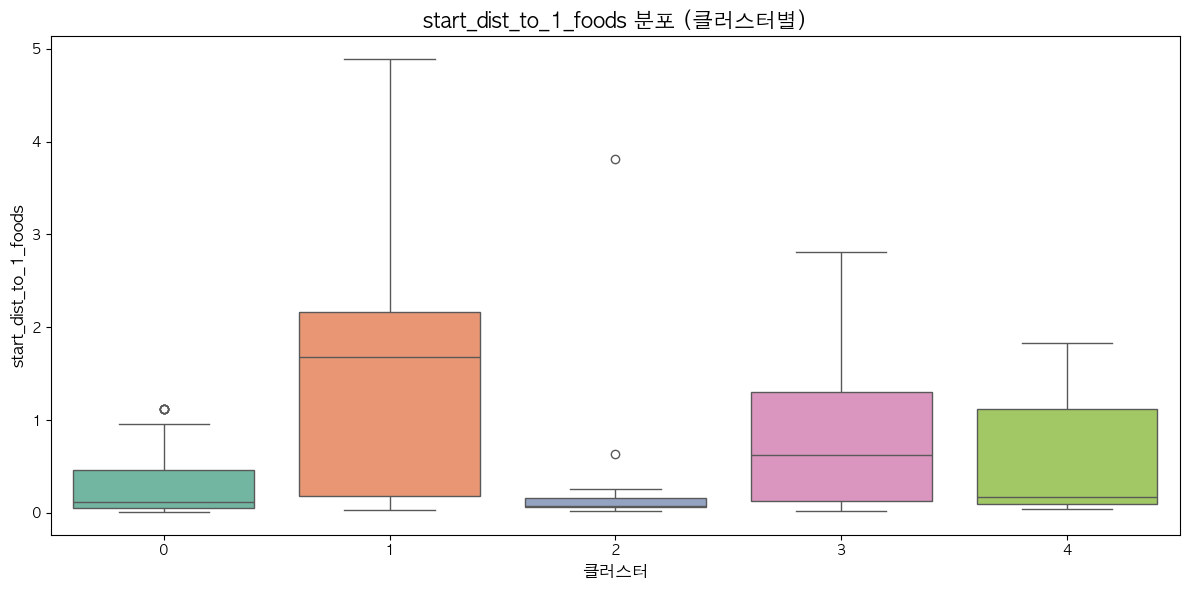

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


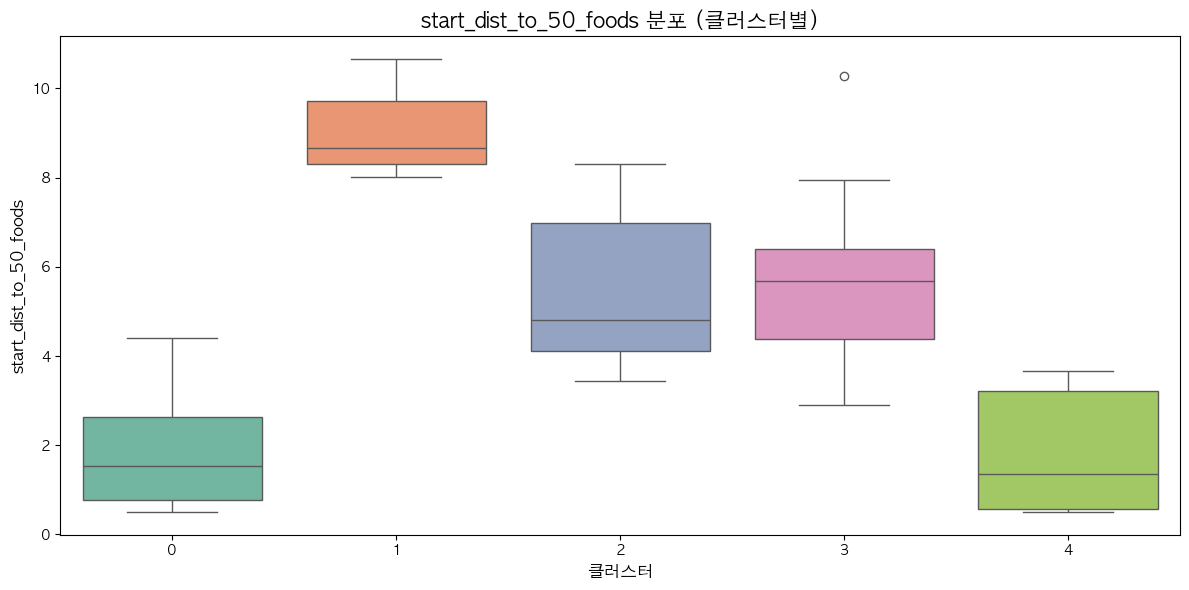

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


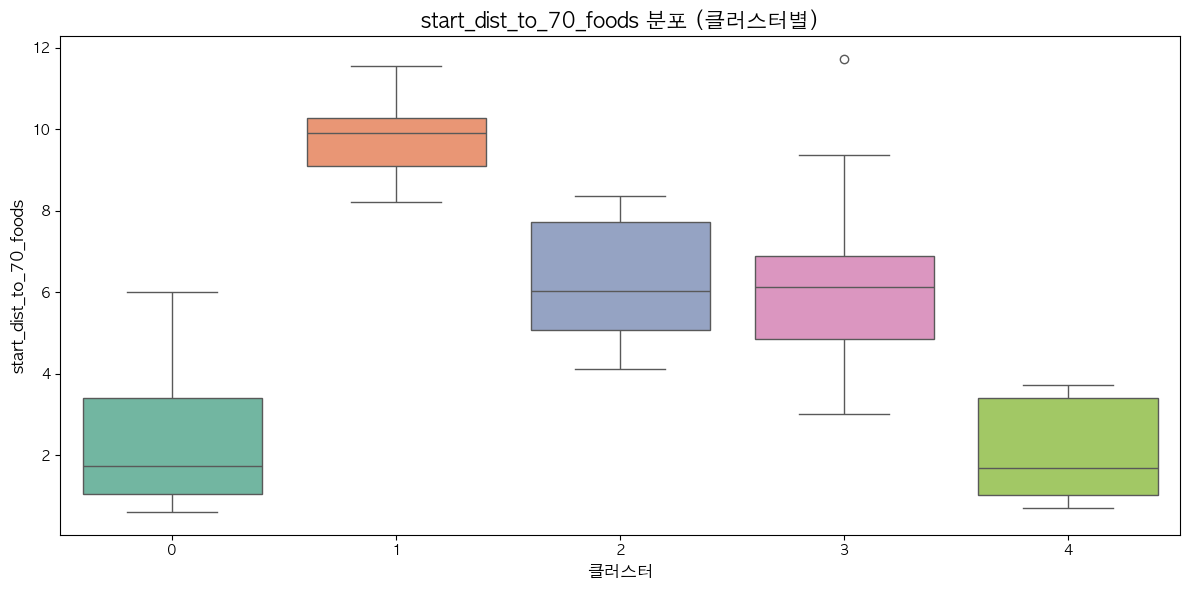

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


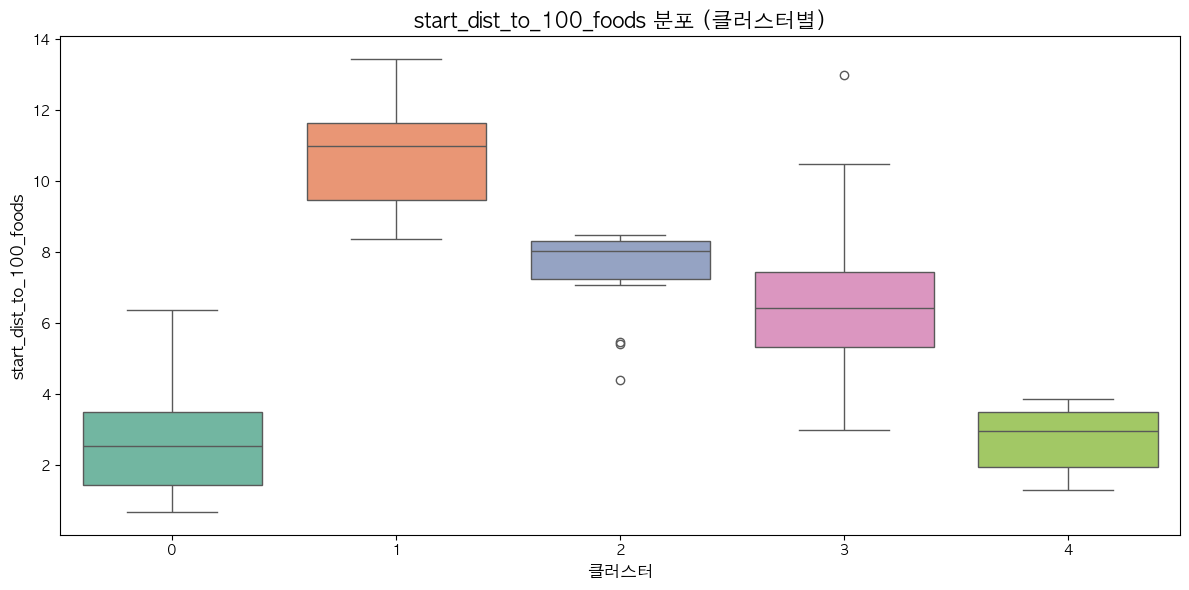

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


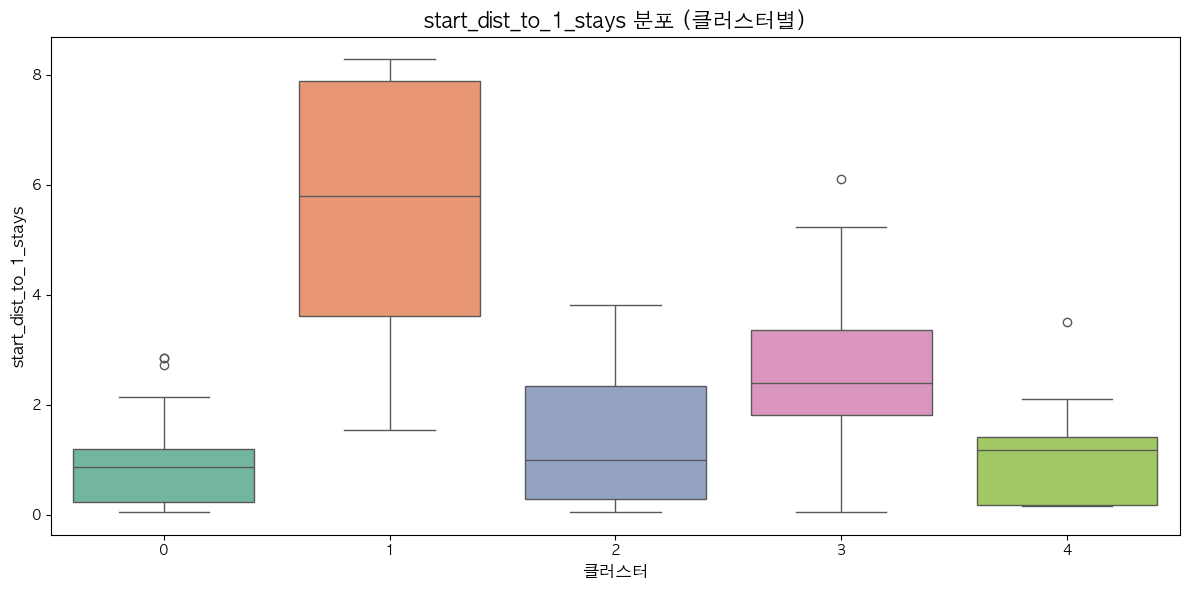

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


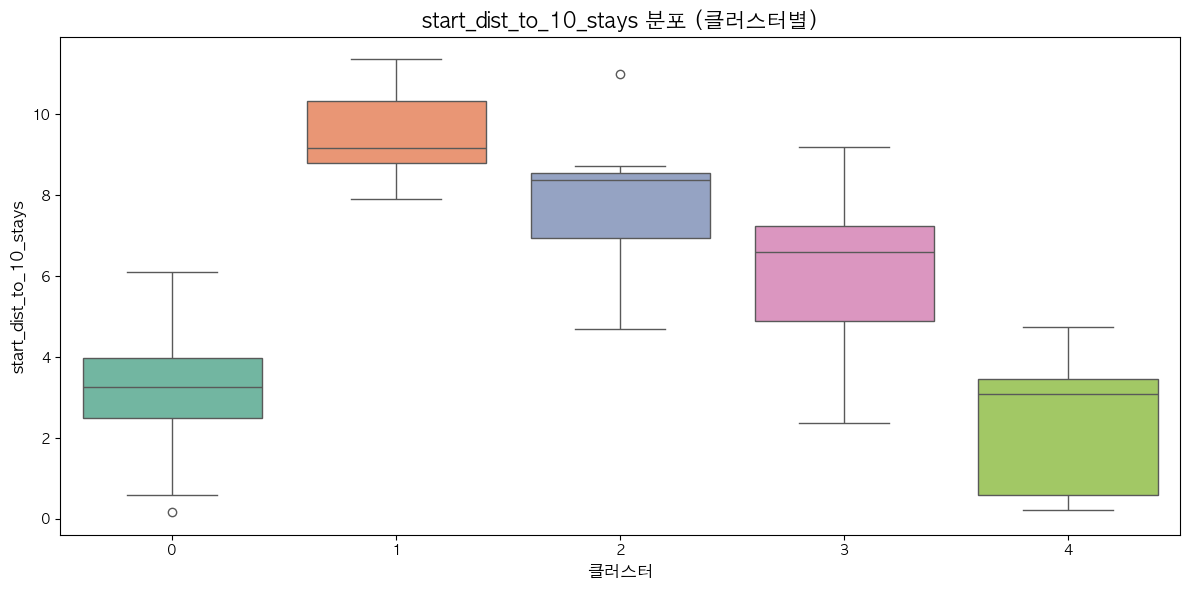

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


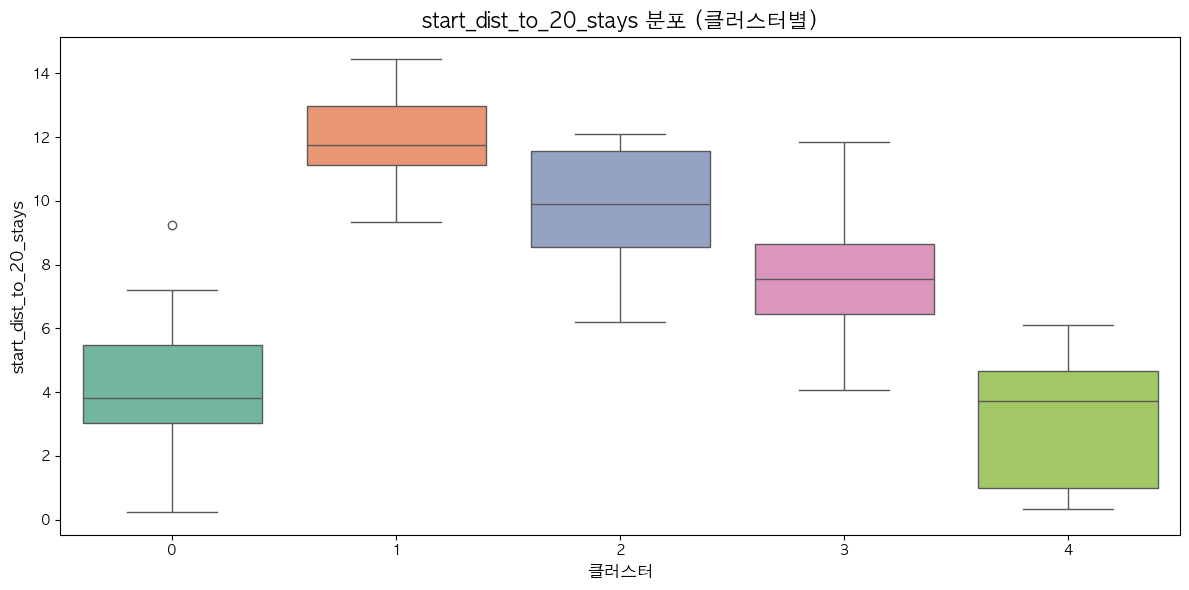

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


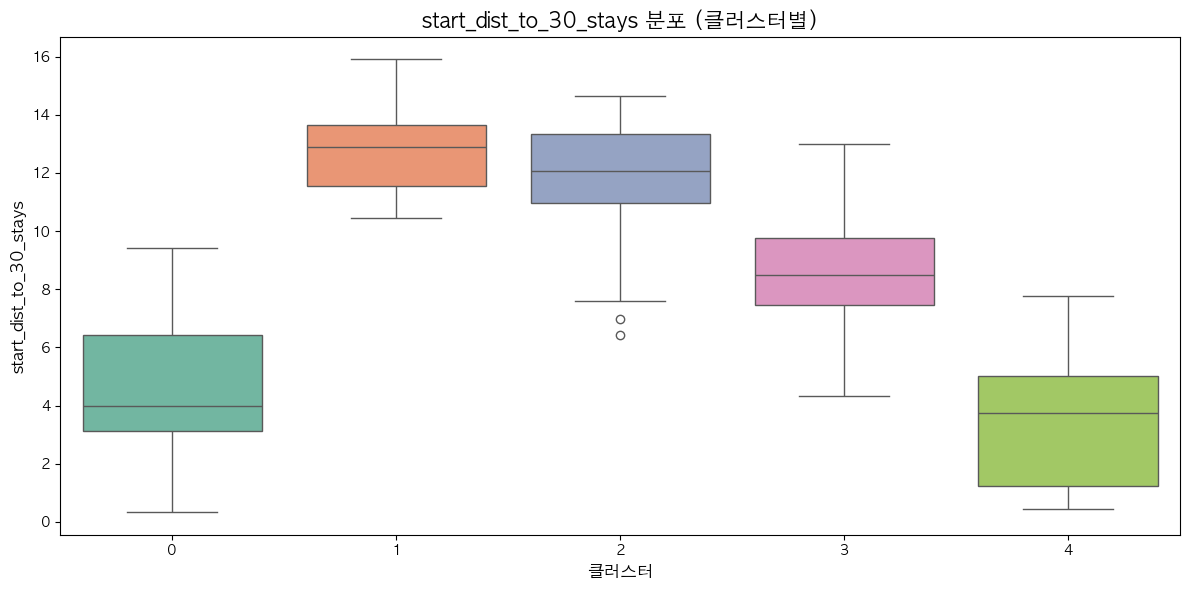

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


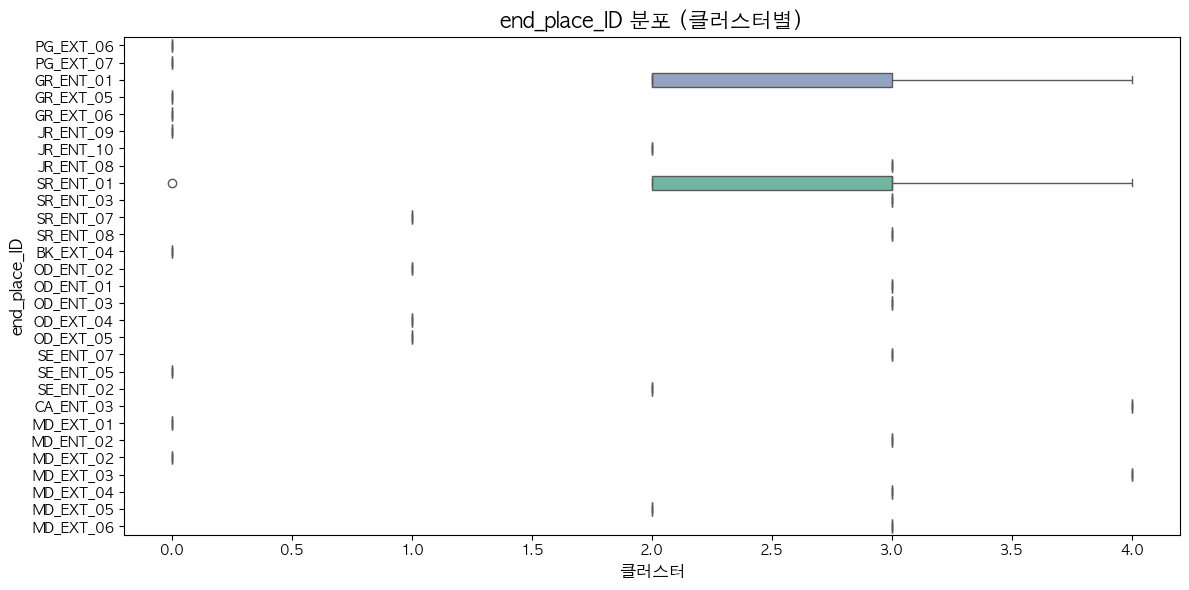

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


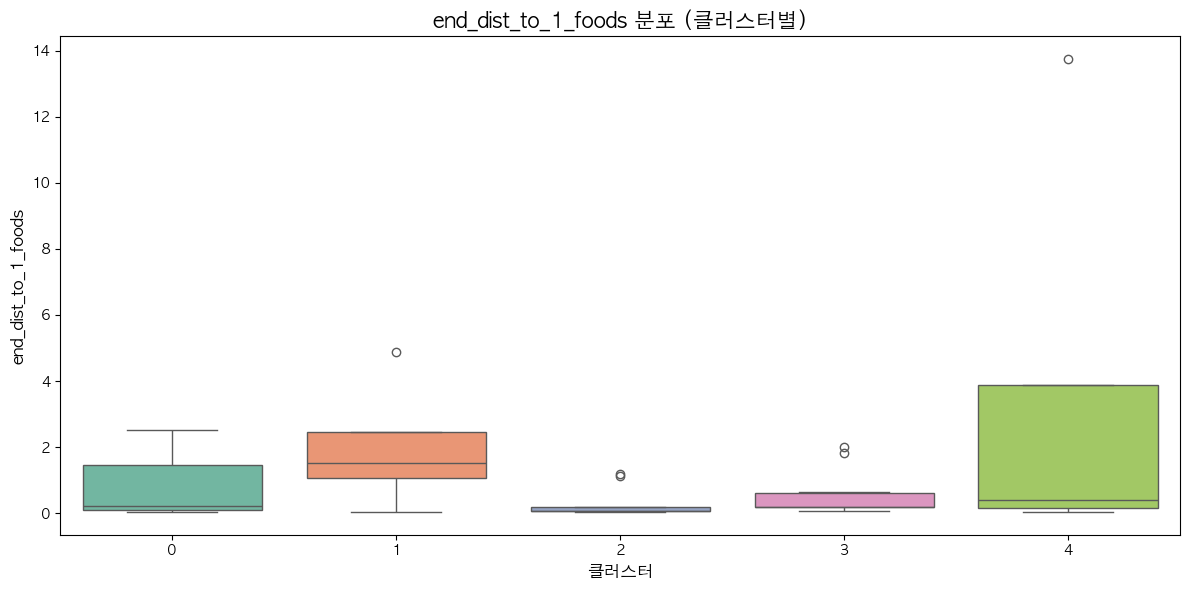

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


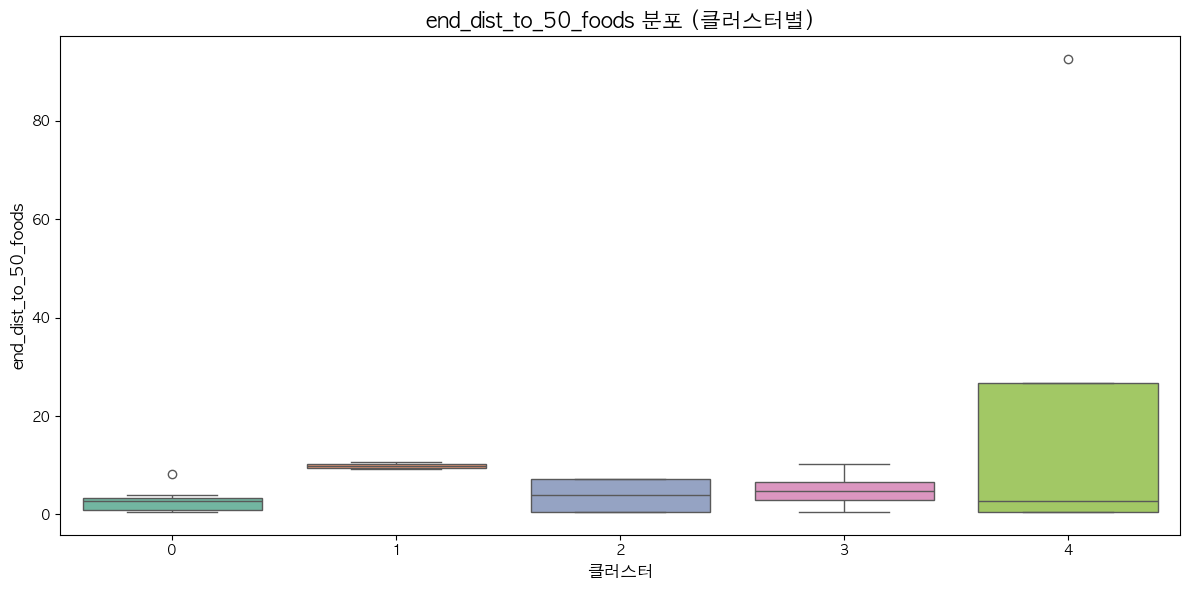

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


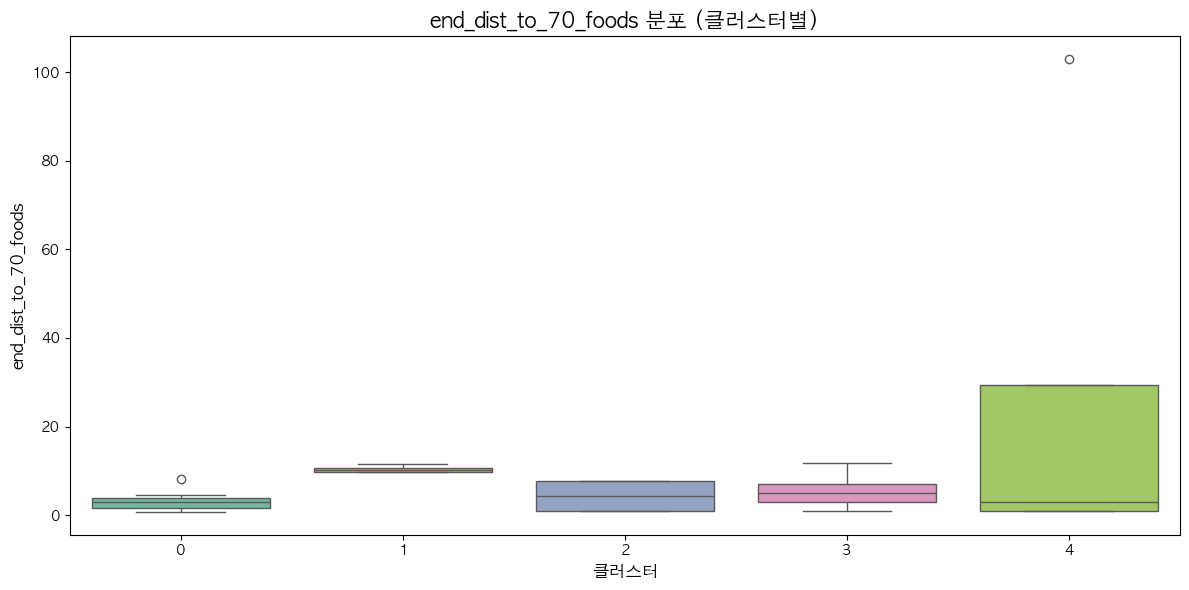

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


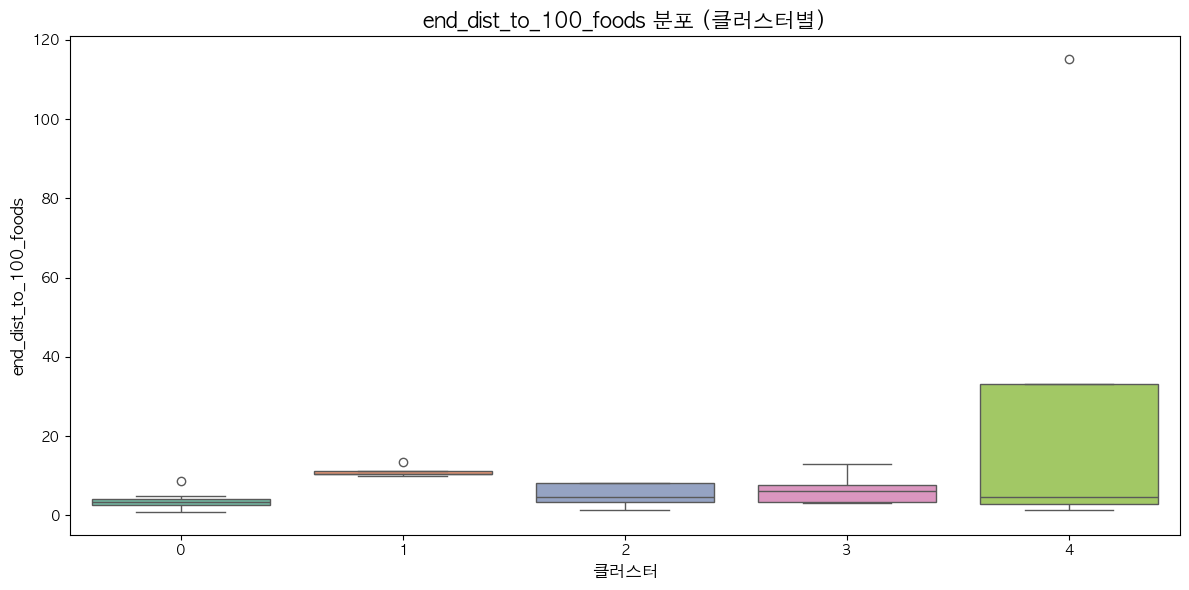

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


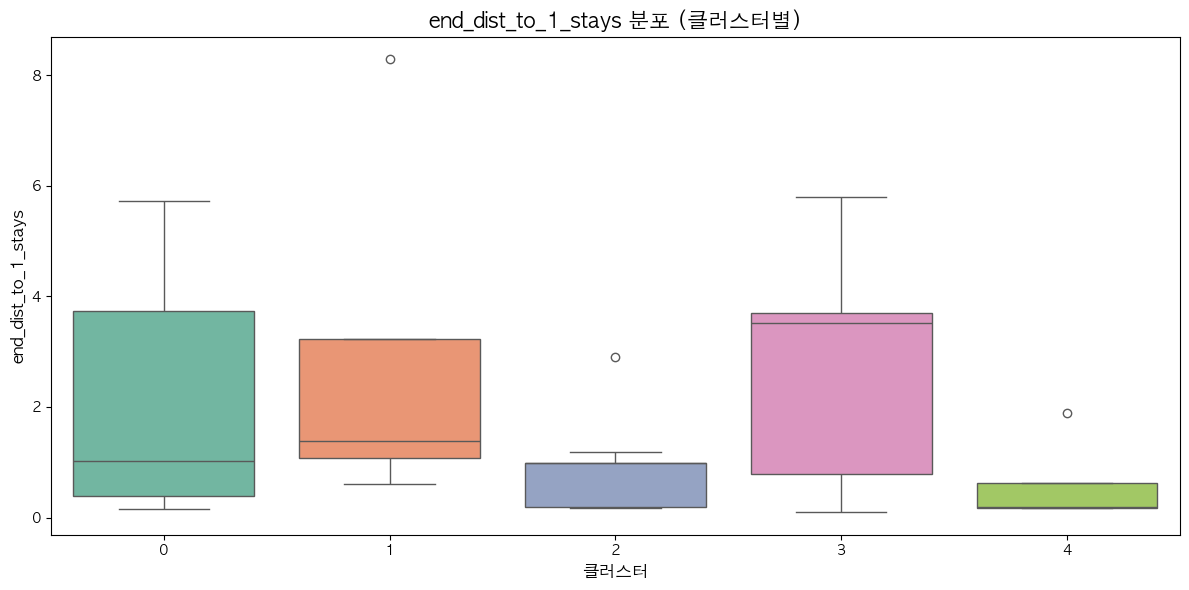

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


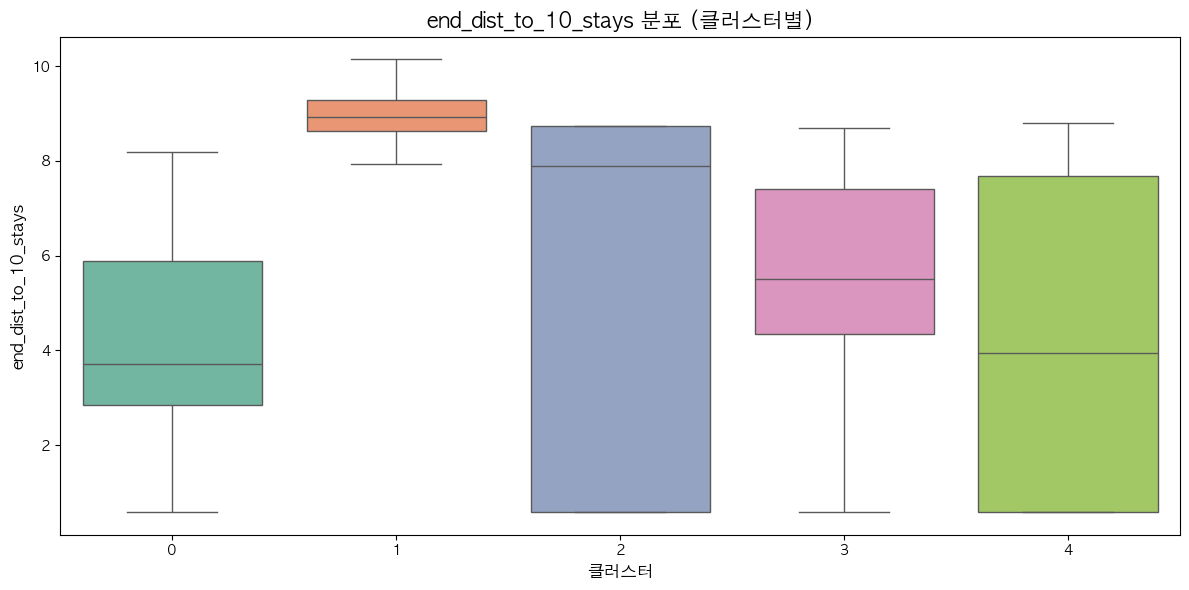

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


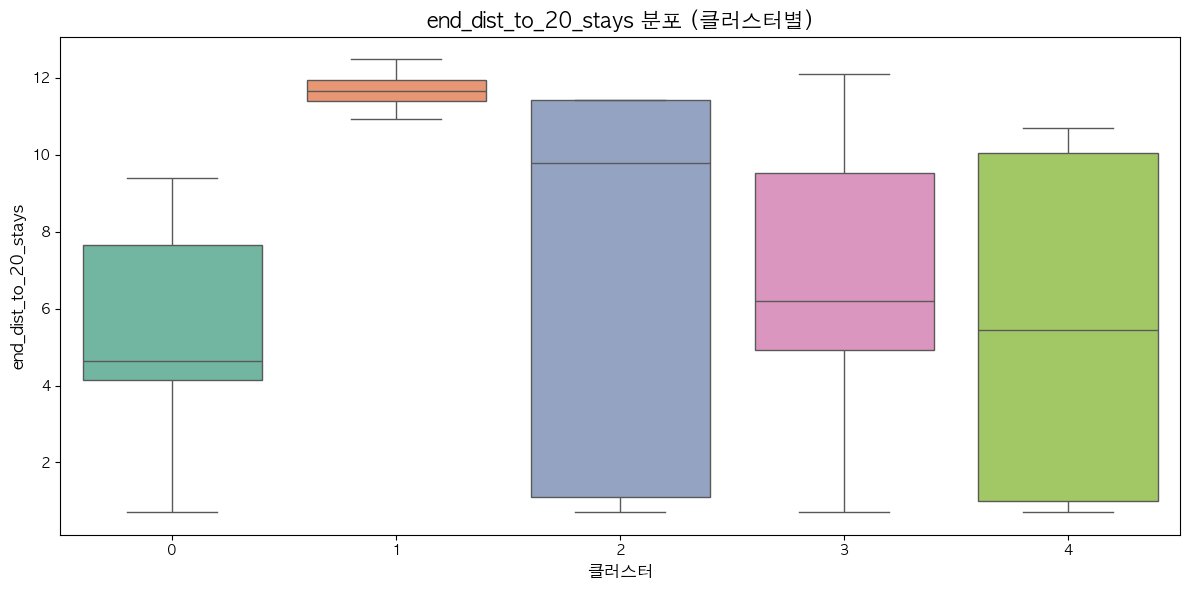

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


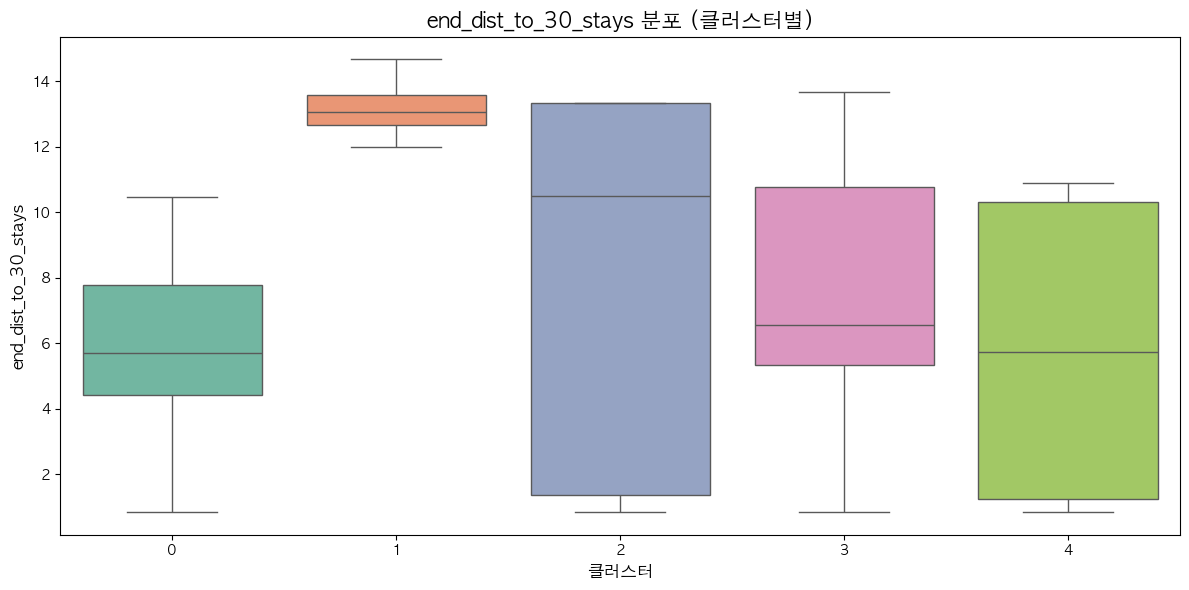

/var/folders/qb/321sn6b122v_ybdr15388h100000gn/T/ipykernel_49241/868395363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')


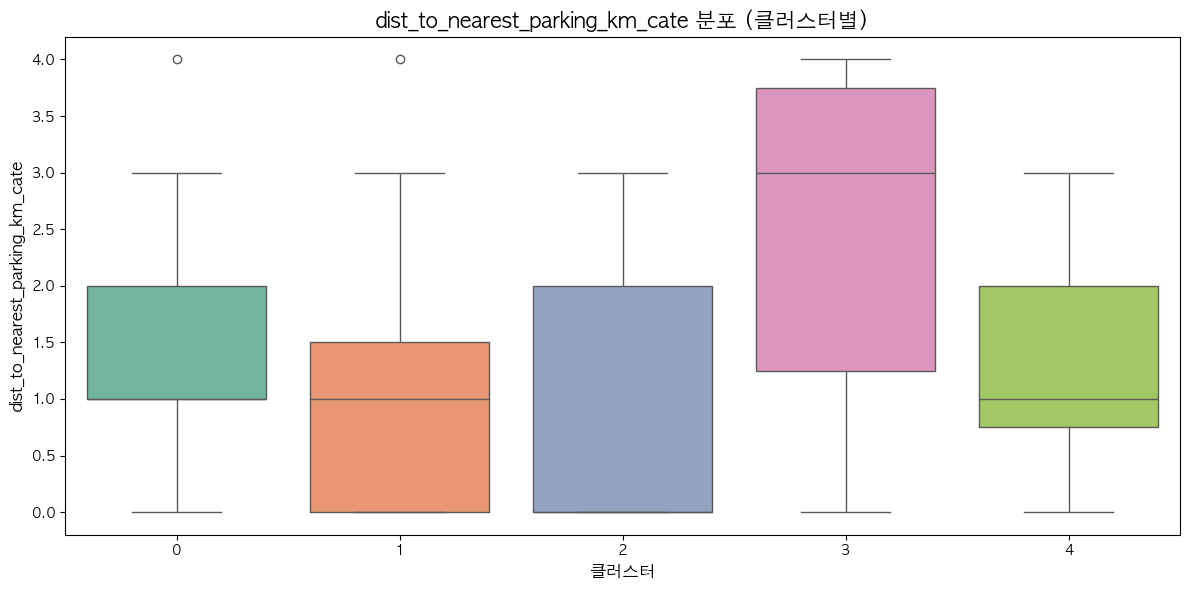

In [55]:
# 'cluster'를 제외한 모든 컬럼에 대해 반복
features = [col for col in original_with_label.columns if col != 'label']

for col in features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=original_with_label, x='label', y=col, palette='Set2')
    plt.title(f"{col} 분포 (클러스터별)", fontsize=15)
    plt.xlabel("클러스터", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

In [52]:
original_with_label.columns

Index(['mountain_name', 'course_name', 'course_id', 'start_point_name',
       'start_point_id', 'start_lat', 'start_lon', 'end_point_name',
       'end_point_id', 'end_lat', 'end_lon', 'schedule', 'distance_km',
       'duration_min', 'attraction_list', 'attraction_count', 'difficulty',
       'sunset_summer', 'sunset_winter', 'shelter_count',
       'dist_to_nearest_parking_km', 'walkable_to_public_transport',
       'start_place_ID', 'start_dist_to_1_foods', 'start_dist_to_50_foods',
       'start_dist_to_70_foods', 'start_dist_to_100_foods',
       'start_dist_to_1_stays', 'start_dist_to_10_stays',
       'start_dist_to_20_stays', 'start_dist_to_30_stays', 'end_place_ID',
       'end_dist_to_1_foods', 'end_dist_to_50_foods', 'end_dist_to_70_foods',
       'end_dist_to_100_foods', 'end_dist_to_1_stays', 'end_dist_to_10_stays',
       'end_dist_to_20_stays', 'end_dist_to_30_stays',
       'dist_to_nearest_parking_km_cate', 'label'],
      dtype='object')

In [58]:
original_with_label[original_with_label['label']==0][['course_name','distance_km','duration_min', 'attraction_count', 'difficulty','start_dist_to_1_foods', 'start_dist_to_1_stays']]

,course_name,distance_km,duration_min,attraction_count,difficulty,start_dist_to_1_foods,start_dist_to_1_stays
0,수태골∼동봉,3.85,115,4,2,0.320000,0.820000
1,진남문∼가산봉,4.70,155,5,1,0.590000,1.280000
4,부인사∼서봉,8.40,320,5,3,0.400000,1.490000
6,탑골∼동봉,3.25,125,5,3,0.020000,0.270000
7,파계사∼파계재,5.20,175,7,2,0.090000,0.230000
8,관암사∼관봉,4.00,170,5,2,0.030000,0.230000
9,동학사 1코스 (편도),4.40,150,4,2,0.040000,0.170000
11,갑사 1코스 (편도),3.80,150,7,2,0.130000,0.050000
13,신원사 1코스 (편도),3.20,290,4,2,0.060000,1.160000
15,수통골 1코스 (편도),3.20,150,3,2,0.050000,2.850000


In [59]:
original_with_label[original_with_label['label']==1][['course_name','distance_km','duration_min', 'attraction_count', 'difficulty','start_dist_to_1_foods', 'start_dist_to_1_stays']]

,course_name,distance_km,duration_min,attraction_count,difficulty,start_dist_to_1_foods,start_dist_to_1_stays
46,대야산코스,4.8,290,3,2,1.400000,1.540000
65,두로봉코스,10.0,280,3,3,0.072612,5.798712
66,동대산코스,4.4,130,1,2,0.072612,5.798712
67,상왕봉코스,14.1,330,4,3,4.892002,8.282411
69,비로봉코스,3.4,100,3,2,4.892002,8.282411
71,계방산1코스,8.9,360,3,2,2.053128,2.842899
72,계방산2코스,8.9,310,1,2,2.053128,2.842899
81,대승폭포코스,0.9,40,3,1,2.510000,5.730000
87,남덕유산코스,3.6,150,2,3,1.960000,3.880000
90,삿갓재코스,3.4,100,2,2,0.030000,8.040000


In [60]:
original_with_label[original_with_label['label']==2][['course_name','distance_km','duration_min', 'attraction_count', 'difficulty','start_dist_to_1_foods', 'start_dist_to_1_stays']]

,course_name,distance_km,duration_min,attraction_count,difficulty,start_dist_to_1_foods,start_dist_to_1_stays
12,갑사 2코스 (종주),10.2,360,9,3,0.13,0.05
14,신원사 2코스 (종주),9.9,360,9,3,0.06,1.16
20,뱀사골계곡코스,9.2,260,8,2,0.26,0.45
27,중산리(장터목)코스,12.4,540,9,2,0.06,0.99
28,중산리(칼바위)코스,10.8,480,5,2,0.06,0.99
29,백무동~중산리코스,12.9,540,8,2,0.06,0.11
30,백무동코스,15.0,660,2,2,0.06,0.11
31,거림코스,18.9,690,9,2,0.02,3.47
32,유평(대원사)코스,21.5,750,6,3,0.08,2.45
35,천왕봉2코스,12.9,420,8,3,0.63,2.38


In [ ]:
original_with_label[original_with_label['label']==3][['distance_km','duration_min', 'attraction_count', 'difficulty','start_dist_to_1_foods', 'start_dist_to_1_stays']]

,distance_km,duration_min,attraction_count,difficulty,start_dist_to_1_foods,start_dist_to_1_stays
19,8.3,300,3,2,0.02,0.43
27,12.4,540,9,2,0.06,0.99
28,10.8,480,5,2,0.06,0.99
29,12.9,540,8,2,0.06,0.11
30,15.0,660,2,2,0.06,0.11
31,18.9,690,9,2,0.02,3.47
32,21.5,750,6,3,0.08,2.45
36,12.0,420,8,3,0.13,0.10
37,7.0,240,5,2,0.10,0.05
38,8.0,270,9,2,0.07,0.81


In [61]:
original_with_label[original_with_label['label']==4][['course_name','distance_km','duration_min', 'attraction_count', 'difficulty','start_dist_to_1_foods', 'start_dist_to_1_stays']]

,course_name,distance_km,duration_min,attraction_count,difficulty,start_dist_to_1_foods,start_dist_to_1_stays
10,동학사 2코스 (종주),11.8,420,8,3,0.040000,0.170000
34,천왕봉1코스,16.1,480,6,3,0.190000,0.190000
83,대청봉코스(백담),23.9,770,9,3,1.830000,3.510000
85,대청봉코스(설악동),16.0,640,15,3,1.120000,1.190000
86,공룡능선코스,19.1,880,6,3,1.120000,1.190000
96,종주코스,26.9,840,4,4,0.160000,0.160000
106,구룡~향로봉~성남,21.4,600,7,3,0.071151,1.157294
114,시무지기폭포 코스,12.0,355,13,2,0.100000,2.100000


In [67]:
# 클러스터별 평균 확인
cluster_profile = original_with_label.groupby('label').mean(numeric_only=True)
display(cluster_profile)

,start_lat,start_lon,end_lat,end_lon,schedule,distance_km,duration_min,attraction_count,difficulty,shelter_count,...,start_dist_to_30_stays,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,dist_to_nearest_parking_km_cate
label,,,,,,,,,,,,,,,,,,,,,
0,36.925747,127.710094,36.251789,127.694527,1.000000,4.738776,155.918367,4.489796,1.673469,0.102041,...,4.509494,0.760958,2.723162,3.097526,3.669044,2.046688,4.111711,5.358052,5.847056,1.326531
1,37.031516,128.198583,37.463397,128.363394,1.000000,6.016667,198.333333,2.416667,2.083333,0.000000,...,12.708016,1.997172,9.929413,10.364090,11.096239,2.915298,8.982128,11.683626,13.184943,1.250000
2,35.991632,127.677861,35.828862,127.638416,1.333333,13.033333,477.333333,8.000000,2.400000,0.800000,...,11.552667,0.314444,4.193333,4.622222,5.147778,0.953333,5.317778,6.901111,7.910000,1.000000
3,36.296219,127.876548,36.053630,127.699888,1.000000,7.282353,218.382353,4.176471,2.000000,0.058824,...,8.497984,0.583735,4.844887,5.286755,6.254661,2.806885,5.420714,6.590567,7.385583,2.382353
4,36.967233,127.907737,36.675541,127.727141,1.500000,18.400000,623.125000,8.500000,3.000000,0.750000,...,3.622775,3.645617,24.612151,27.467162,31.391963,0.609257,4.323371,5.580863,5.803756,1.250000


In [68]:
cluster_profile[['schedule', 'distance_km','duration_min','attraction_count', 'difficulty',
                  'shelter_count',
                 'dist_to_nearest_parking_km_cate', 'walkable_to_public_transport',
                 'start_dist_to_1_foods', 'start_dist_to_50_foods',
                'start_dist_to_70_foods', 'start_dist_to_100_foods',
                'start_dist_to_1_stays', 'start_dist_to_10_stays',
                'start_dist_to_20_stays', 'start_dist_to_30_stays']]

,schedule,distance_km,duration_min,attraction_count,difficulty,shelter_count,dist_to_nearest_parking_km_cate,walkable_to_public_transport,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays
label,,,,,,,,,,,,,,,,
0,1.000000,4.738776,155.918367,4.489796,1.673469,0.102041,1.326531,0.918367,0.307967,1.776504,2.154652,2.670262,0.926060,3.089049,4.037224,4.509494
1,1.000000,6.016667,198.333333,2.416667,2.083333,0.000000,1.250000,0.666667,1.717957,9.047519,9.772349,10.778844,5.725670,9.429537,11.780132,12.708016
2,1.333333,13.033333,477.333333,8.000000,2.400000,0.800000,1.000000,0.666667,0.380000,5.358667,6.326667,7.398000,1.332667,7.735333,9.906000,11.552667
3,1.000000,7.282353,218.382353,4.176471,2.000000,0.058824,2.382353,0.794118,0.822889,5.550844,6.059486,6.567136,2.462854,6.232831,7.596526,8.497984
4,1.500000,18.400000,623.125000,8.500000,3.000000,0.750000,1.250000,1.000000,0.578894,1.800392,2.064537,2.710781,1.208412,2.450297,3.217961,3.622775


In [69]:
original_with_label[original_with_label['mountain_name']=='치악산']

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,...,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,dist_to_nearest_parking_km_cate,label
100,치악산,금대~남대봉,CA_01,금대분소,CA_ENT_01,37.293013,128.017735,남대봉,CA_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
101,치악산,행구동~향로봉,CA_02,행구탐방지원센터,CA_ENT_02,37.333289,128.014485,향로봉,CA_EXT_02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
102,치악산,성남~남대봉,CA_03,성남탐방지원센터,CA_ENT_03,37.280921,128.085242,남대봉,CA_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3
103,치악산,부곡~곧은재~비로봉,CA_04,부곡탐방지원센터,CA_ENT_04,37.333163,128.074154,비로봉,CA_EXT_03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3
104,치악산,구룡~세렴폭포,CA_05,구룡탐방지원센터,CA_ENT_05,37.414398,128.050061,세렴폭포,CA_EXT_04,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
105,치악산,구룡~비로봉,CA_06,구룡문화재매표소,CA_ENT_06,37.399761,128.050029,비로봉,CA_EXT_03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0
106,치악산,구룡~향로봉~성남,CA_07,구룡탐방지원센터,CA_ENT_05,37.414398,128.050061,성남탐방지원센터,CA_ENT_03,37.280921,...,13.752468,92.638606,103.018647,115.21785,0.177027,7.313483,9.813451,10.105024,0,4
107,치악산,황골~비로봉,CA_08,황골탐방지원센터,CA_ENT_07,37.360152,128.022102,비로봉,CA_EXT_03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
108,치악산,부곡~곧은재~비로봉,CA_09,부곡탐방지원센터,CA_ENT_04,37.333163,128.074154,곧은재,CA_EXT_05,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3
109,치악산,금대~영원산성~남대봉,CA_10,금대분소,CA_ENT_01,37.293013,128.017735,남대봉,CA_EXT_01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


| 클러스터 | 거리 | 시간 | 난이도 | 명소 수 | 접근성 | 숙박/식당 거리 | 특징 요약 |
|----------|------|------|--------|---------|--------|----------------|------------|
| **0**    | 짧음 | 짧음 | 낮음   | 보통    | 주차는 멂 | 식당·숙소는 가까움 | 입문자/가족형 |
| **1**    | 짧음 | 짧음 | 보통   | 적음    | 중간    | **아주 멂**        | 외진 쉬운 코스 |
| **2**    | 김   | 김   | 보통↑ | 많음    | 좋음    | 가까움          | 고도 탐방형 (체력 필요) |
| **3**    | 중간 | 중간 | 보통   | 보통    | **가장 멂** | 멂             | 외곽 중급 코스 |
| **4**    | 김   | 김   | 높음   | 많음    | 중간    | 가까움          | 숙박형 장거리 코스 |

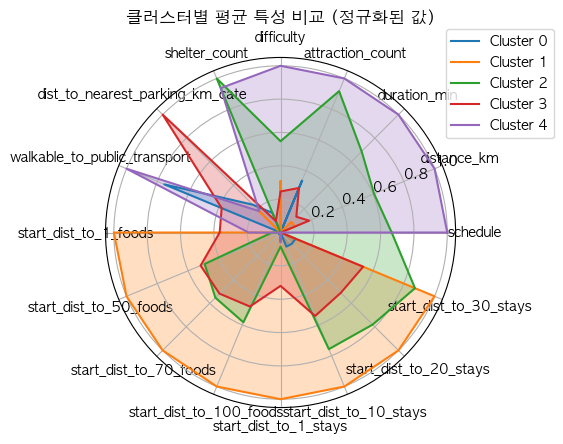

In [70]:
original_with_label_2 = original_with_label[['schedule', 'distance_km','duration_min','attraction_count', 'difficulty',
                  'shelter_count',
                 'dist_to_nearest_parking_km_cate', 'walkable_to_public_transport',
                 'start_dist_to_1_foods', 'start_dist_to_50_foods',
                'start_dist_to_70_foods', 'start_dist_to_100_foods',
                'start_dist_to_1_stays', 'start_dist_to_10_stays',
                'start_dist_to_20_stays', 'start_dist_to_30_stays', 'label']]

# 클러스터 평균 구하기
cluster_mean = original_with_label_2.groupby('label').mean()

# 정규화
scaler = MinMaxScaler()
cluster_mean_scaled = pd.DataFrame(scaler.fit_transform(cluster_mean), columns=cluster_mean.columns)
cluster_mean_scaled['label'] = cluster_mean.index

# 레이더 차트 그리기
labels = cluster_mean.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for i, row in cluster_mean_scaled.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {int(row["label"])}')
    ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('클러스터별 평균 특성 비교 (정규화된 값)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()